# **Understanding Simple RNN Fundamentals**


### What is a Simple RNN?

A Simple RNN (Recurrent Neural Network) is the most basic form of recurrent neural network that can process sequences of data by maintaining a "memory" of previous inputs.

Key Characteristics:

- Sequential Processing: Processes data one time step at a time

- Memory: Maintains hidden state that carries information from previous time steps

- Parameter Sharing: Uses the same weights across all time steps

- Suitable for: Short sequences (5-10 time steps) due to vanishing gradient problem



### Simple RNN Architecture

In [1]:
# Basic Simple RNN structure
# Input: [batch_size, sequence_length, features]
# Hidden State: [batch_size, hidden_units]
# Output: [batch_size, output_units]


### Change Working directory

In [2]:
import os
os.chdir('/Users/macbookairm4chip/Desktop/DAM202-SEM5/Practical3')
os.listdir()

['weather_data.csv',
 'bin',
 'include',
 'etc',
 'pyvenv.cfg',
 'Practical3',
 'Practical3.ipynb',
 'lib',
 '.ipynb_checkpoints',
 'share']

### 1.1 Installation and Imports

In [7]:
#Install required packages (run in terminal)
%pip install tensorflow pandas numpy matplotlib scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras for Simple RNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input

# Data preprocessing tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully!")


/Users/macbookairm4chip/Desktop/DAM202-SEM5/Practical3/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0
Setup completed successfully!


### 1.2 Data Loading and Exploration

#### 1.2.1  Load Bangladesh Weather Data

In [9]:
def load_weather_data(file_path):
    df = pd.read_csv(file_path)

    print("CSV columns:", df.columns.tolist())  # 👈 check real names
    print(df.head())  # 👈 preview data

    # Define expected names
    column_names = [
        'Year', 'Day', 'Wind_Speed', 'Specific_Humidity',
        'Relative_Humidity', 'Precipitation', 'Temperature'
    ]

    # Assign names only if lengths match
    if len(df.columns) == len(column_names):
        df.columns = column_names

    # Only build Date if Year + Day exist
    if 'Year' in df.columns and 'Day' in df.columns:
        df['Date'] = pd.to_datetime(df['Year'] * 1000 + df['Day'], format='%Y%j')
        df.set_index('Date', inplace=True)
        df.drop(['Year', 'Day'], axis=1, inplace=True)
    else:
        print("⚠️ No 'Year' and 'Day' columns found, skipping Date conversion")

    return df


# Load your data
data_file = "/Users/macbookairm4chip/Desktop/DAM202-SEM5/Practical3/weather_data.csv"
df = load_weather_data(data_file)


CSV columns: ['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  
⚠️ No 'Year' and 'Day' columns found, skipping Date conversion


In [10]:
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


#### 1.2.2 Data Exploration and Visualization

In [12]:
def explore_weather_data(df):
    """
    Comprehensive exploration of weather data
    """

    print("=== BANGLADESH WEATHER DATA EXPLORATION ===")
    print(f"Dataset Shape: {df.shape}")

    # ✅ Check if index is datetime
    if isinstance(df.index, pd.DatetimeIndex):
        print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
        print(f"Total Days: {len(df)} days")
        print(f"Years Covered: {df.index.year.nunique()} years")
    else:
        print("⚠️ Index is not datetime — skipping Date Range summary")

    # Basic statistics
    print("\n=== BASIC STATISTICS ===")
    print(df.describe().round(2))

    # Check for missing values
    print("\n=== MISSING VALUES ===")
    missing_values = df.isnull().sum()
    print(missing_values)

    # Data types
    print("\n=== DATA TYPES ===")
    print(df.dtypes)

    # Visualize all weather variables
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        axes[i].plot(df.index, df[column], alpha=0.7, linewidth=0.5)
        axes[i].set_title(f'{column} Over Time', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

        # Add some statistics to the plot
        mean_val = df[column].mean()
        axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend()

    plt.tight_layout()
    plt.suptitle('Bangladesh Weather Data (1990-2023)', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df


### 1.3 Data Preprocessing for Simple RNN

#### 1.3.1 Data Cleaning

In [14]:
import pandas as pd

# 1. Load your data
data_file = "/Users/macbookairm4chip/Desktop/DAM202-SEM5/Practical3/weather_data.csv"
df = pd.read_csv(data_file)

# 2. Parse datetime if you have a Date column
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

# 3. Quick exploration
print("=== RAW DATA PREVIEW ===")
print(df.head())
print(df.info())

# Assign df_explored for later use
df_explored = df.copy()


# 4. Cleaning function
def clean_weather_data(df):
    """
    Clean the weather data for Simple RNN processing
    """

    print("=== DATA CLEANING PROCESS ===")

    # Make a copy to avoid modifying original data
    df_clean = df.copy()

    # 1. Handle missing values
    print(f"Missing values before cleaning: {df_clean.isnull().sum().sum()}")

    # Forward fill then backward fill for time series data
    df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

    print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

    # 2. Remove outliers using IQR method
    print("\n=== OUTLIER REMOVAL ===")

    for column in df_clean.select_dtypes(include="number").columns:  # only numeric cols
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers_before = ((df_clean[column] < lower_bound) |
                           (df_clean[column] > upper_bound)).sum()

        # Remove outliers by clipping
        df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)

        print(f"{column}: {outliers_before} outliers handled")

    # 3. Basic feature engineering for time series
    if isinstance(df_clean.index, pd.DatetimeIndex):
        df_clean['Month'] = df_clean.index.month
        df_clean['Day_of_Year'] = df_clean.index.dayofyear

    # Add simple moving averages (helpful for Simple RNN)
    if "Temperature" in df_clean.columns:
        df_clean['Temp_MA_3'] = df_clean['Temperature'].rolling(window=3).mean()
        df_clean['Temp_MA_7'] = df_clean['Temperature'].rolling(window=7).mean()

    # Remove rows with NaN values created by moving averages
    df_clean.dropna(inplace=True)

    print(f"\nFinal dataset shape: {df_clean.shape}")

    return df_clean


# 5. Clean the data
df_clean = clean_weather_data(df_explored)

# Preview cleaned data
print("\n=== CLEANED DATA PREVIEW ===")
print(df_clean.head())


=== RAW DATA PREVIEW ===
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  object 
 1   Date_Time         1000000 non-null  object 
 2   Temperature_C     10

/var/folders/46/yg85ttms2s9flq5kj1dyw0k80000gn/T/ipykernel_7823/3093609661.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')


Missing values after cleaning: 0

=== OUTLIER REMOVAL ===
Temperature_C: 0 outliers handled
Humidity_pct: 0 outliers handled
Precipitation_mm: 0 outliers handled
Wind_Speed_kmh: 0 outliers handled

Final dataset shape: (1000000, 6)

=== CLEANED DATA PREVIEW ===
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  


In [15]:
df_clean.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


# This is formatted as code


#### 1.3.2 Data Normalization (Critical for Simple RNN)

In [16]:
def normalize_data_for_rnn(df, target_column='Temperature'):
    """
    Normalize data for Simple RNN training

    Important: We fit the scaler only on training data to prevent data leakage
    """

    print(f"=== DATA NORMALIZATION FOR SIMPLE RNN ===")
    print(f"Target variable: {target_column}")

    # Separate features and target
    feature_columns = [col for col in df.columns if col != target_column]

    print(f"Feature columns: {feature_columns}")
    print(f"Number of features: {len(feature_columns)}")

    # Initialize scalers
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    return df, feature_columns, feature_scaler, target_scaler

# Prepare for normalization
df_processed, feature_columns, feature_scaler, target_scaler = normalize_data_for_rnn(df_clean)

=== DATA NORMALIZATION FOR SIMPLE RNN ===
Target variable: Temperature
Feature columns: ['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Number of features: 6


In [17]:
df_processed.head(2)

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161


These lines are for basic feature engineering in time series analysis, which helps a neural network learn patterns better by adding informative features derived from the raw data.

What are these features?
- Month: The month from each date (e.g., January, February, etc.), which helps encode potential seasonal effects (like monsoons or cold seasons).

- Day_of_Year: The position of each date in the year (e.g., 1 for January 1st, 365 for December 31st), which can capture cyclic trends and annual seasonality.

- Temp_MA_3: The average temperature over the past 3 days for each day.

- Temp_MA_7: The average temperature over the past 7 days for each day.

Why are they done?
- Month and Day_of_Year transform raw date information into numerical features so that machine learning models can learn from seasonal patterns (e.g., temperature might be higher in June than in December).

- Moving averages (Temp_MA_3 and Temp_MA_7) smooth the original temperature signal. They reduce noise and short-term fluctuations, making longer-term trends and cycles more visible for the model. These features help the neural network understand not just today's temperature but also recent context, which is important for forecasting.

Why do we do this for time series models?
- Expose Patterns: Weather data shows seasonal/cyclic behaviors; encoding month and day-of-year helps the model pick up on regular patterns.

- Reduce Noise: Moving averages help to “smooth out” outlier values, giving the model a clearer picture of underlying trends.

Learning Context: RNNs thrive when they can access recent history. Including moving averages lets the model access summarized context of the recent past, not just raw daily values

#### 1.3.3 Time Series Train-Test Split

In [18]:
def create_time_series_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Create time-aware train/validation/test split for time series

    Important: No shuffling to maintain temporal order!
    """

    print(f"=== TIME SERIES DATA SPLITTING ===")

    n_samples = len(df)

    # Calculate split indices
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))

    # Split data maintaining temporal order
    train_data = df.iloc[:train_end].copy()
    val_data = df.iloc[train_end:val_end].copy()
    test_data = df.iloc[val_end:].copy()

    print(f"Training data: {len(train_data)} samples ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Validation data: {len(val_data)} samples ({val_data.index.min()} to {val_data.index.max()})")
    print(f"Test data: {len(test_data)} samples ({test_data.index.min()} to {test_data.index.max()})")

    return train_data, val_data, test_data

# Split the data
train_data, val_data, test_data = create_time_series_split(df_processed)

=== TIME SERIES DATA SPLITTING ===
Training data: 700000 samples (0 to 699999)
Validation data: 150000 samples (700000 to 849999)
Test data: 150000 samples (850000 to 999999)


In [19]:
train_data.head(2)

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161


### 1.4 Creating Sequences for Simple RNN

#### Understanding Sequence Creation
Simple RNNs work best with shorter sequences (5-7 days) due to the vanishing gradient problem. Here's how we create sequences:

In [20]:
def create_sequences_for_simple_rnn(features, target, sequence_length=5):
    """
    Create sequences for Simple RNN training

    For Simple RNN, we use shorter sequences (5-7 days) for better performance

    Parameters:
    - data: scaled data array
    - target_column: index of target column
    - sequence_length: number of time steps to look back (keep it short for Simple RNN)
    """

    sequences = []
    targets = []

    # Create sequences
    for i in range(sequence_length, len(features)):
        # Get sequence of past 'sequence_length' days
        sequences.append(features[i-sequence_length:i])  # Shape: (sequence_length, features)

        # Get target (next day's temperature)
        targets.append(target[i])  # Single value

    return np.array(sequences), np.array(targets)

In [22]:
import numpy as np

def prepare_data_for_simple_rnn(train_data, val_data, test_data,
                               feature_columns, target_column,
                               feature_scaler, target_scaler,
                               sequence_length=5):
    """
    Complete data preparation pipeline for Simple RNN
    """

    print(f"=== PREPARING DATA FOR SIMPLE RNN ===")
    print(f"Sequence length: {sequence_length} days")
    print(f"Target: {target_column}")
    print(f"Features (before filtering): {feature_columns}")

    # --- 1. Keep only numeric feature columns ---
    numeric_features = [col for col in feature_columns if np.issubdtype(train_data[col].dtype, np.number)]
    print(f"Features (numeric only): {numeric_features}")

    # --- 2. Scale the data (fit only on training data!) ---
    train_features_scaled = feature_scaler.fit_transform(train_data[numeric_features])
    train_target_scaled = target_scaler.fit_transform(train_data[[target_column]])
    print(f"Train Target : {train_target_scaled.flatten().shape}")

    val_features_scaled = feature_scaler.transform(val_data[numeric_features])
    val_target_scaled = target_scaler.transform(val_data[[target_column]])

    test_features_scaled = feature_scaler.transform(test_data[numeric_features])
    test_target_scaled = target_scaler.transform(test_data[[target_column]])

    # --- 3. Create sequences ---
    X_train, y_train = create_sequences_for_simple_rnn(
        train_features_scaled, train_target_scaled.flatten(), sequence_length
    )
    X_val, y_val = create_sequences_for_simple_rnn(
        val_features_scaled, val_target_scaled.flatten(), sequence_length
    )
    X_test, y_test = create_sequences_for_simple_rnn(
        test_features_scaled, test_target_scaled.flatten(), sequence_length
    )

    print(f"Training sequences: {X_train.shape}")
    print(f"Training targets: {y_train.shape}")
    print(f"Validation sequences: {X_val.shape}")
    print(f"Test sequences: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


In [25]:
import numpy as np

# Automatically pick only numeric columns from df_clean
numeric_features = [col for col in df_clean.columns if np.issubdtype(df_clean[col].dtype, np.number)]

print("Numeric feature columns:", numeric_features)


Numeric feature columns: ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']


In [28]:
(X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_for_simple_rnn(
    train_data=df_clean.iloc[:700000],    # example split
    val_data=df_clean.iloc[700000:850000],
    test_data=df_clean.iloc[850000:],
    feature_columns=numeric_features,
    target_column='Temperature_C',        # <-- Use the correct column name
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    sequence_length=SEQUENCE_LENGTH
)


=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature_C
Features (before filtering): ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Features (numeric only): ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699995, 5, 4)
Training targets: (699995,)
Validation sequences: (149995, 5, 4)
Test sequences: (149995, 5, 4)


In [29]:
X_train[100]

array([[0.42330191, 0.83010609, 0.66905607, 0.85300006],
       [0.33837371, 0.13797634, 0.7962888 , 0.96795655],
       [0.77428454, 0.14456816, 0.40382528, 0.30990409],
       [0.4722861 , 0.0210802 , 0.04377636, 0.43594695],
       [0.74125026, 0.09987285, 0.28808202, 0.77319247]])

### 1.5 Building Simple RNN Model

#### 1.5.1 Understanding Simple RNN Architecture

In [30]:
def create_simple_rnn_model(input_shape, hidden_units=32, dropout_rate=0.2):
    """
    Create a Simple RNN model optimized for weather prediction

    Architecture:
    1. SimpleRNN layer with specified hidden units
    2. Dropout for regularization
    3. Dense layer for final prediction

    Parameters:
    - input_shape: (sequence_length, number_of_features)
    - hidden_units: number of neurons in RNN layer
    - dropout_rate: dropout rate for regularization
    """

    print(f"=== BUILDING SIMPLE RNN MODEL ===")
    print(f"Input shape: {input_shape}")
    print(f"Hidden units: {hidden_units}")
    print(f"Dropout rate: {dropout_rate}")

    model = Sequential(name="Simple_RNN_Weather_Predictor")

    # Add Input layer to specify input shape
    model.add(Input(shape=input_shape, name='Input_Layer'))

    # Add SimpleRNN layer without input_shape argument
    model.add(SimpleRNN(
        units=hidden_units,
        activation='tanh',  # Default activation
        dropout=dropout_rate,
        recurrent_dropout=dropout_rate,
        name='SimpleRNN_Layer'
    ))


    # Add dropout for additional regularization
    model.add(Dropout(dropout_rate, name='Dropout_Layer'))

    # Add dense layer for final prediction
    model.add(Dense(
        units=1,
        activation='linear',  # Linear activation for regression
        name='Output_Layer'
    ))

    # Compile the model
    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mean_absolute_error', 'mean_absolute_percentage_error']
    )

    # Display model summary
    print("\n=== MODEL ARCHITECTURE ===")
    model.summary()

    return model

# Create the Simple RNN model
input_shape = (X_train.shape[1], X_train.shape[2])  # (sequence_length, features)
model = create_simple_rnn_model(input_shape, hidden_units=32, dropout_rate=0.2)

=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 4)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.5.2 Model Training Strategy

In [31]:
def train_simple_rnn_model(model, X_train, y_train, X_val, y_val,
                          epochs=100, batch_size=32, patience=10):
    """
    Train Simple RNN model with proper callbacks

    Simple RNN training considerations:
    - Lower epochs (50) due to faster convergence
    - Early stopping to prevent overfitting
    - Learning rate reduction for better convergence
    """

    print(f"=== TRAINING SIMPLE RNN MODEL ===")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")

    # Define callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        ModelCheckpoint(
            'best_simple_rnn_model.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train the model
    print("\nStarting training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Important: Don't shuffle time series data
    )

    print("Training completed!")
    return history

# Train the model
training_history = train_simple_rnn_model(
    model, X_train, y_train, X_val, y_val,
    epochs=100, batch_size=32, patience=10
)


=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699995
Validation samples: 149995
Epochs: 100
Batch size: 32

Starting training...
Epoch 1/100
21839/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 0.0679 - mean_absolute_error: 0.2196 - mean_absolute_percentage_error: 595.4326
Epoch 1: val_loss improved from inf to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 13s 565us/step - loss: 0.0679 - mean_absolute_error: 0.2196 - mean_absolute_percentage_error: 595.8984 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7766
Epoch 2/100
21778/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.5291
Epoch 2: val_loss improved from 0.05813 to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 550us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 599.7896 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7737
Epoch 3/100
21782/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.3628
Epoch 3: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 544us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 596.5643 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7164
Epoch 4/100
21871/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 597.0184
Epoch 4: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 545us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 597.0817 - val_

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 545us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.1000 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7600
Epoch 6/100
21787/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 595.6790
Epoch 6: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 545us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 596.8164 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7852
Epoch 7/100
21831/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 594.9304
Epoch 7: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 551us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.5012 - val_

### 1.6 Model Evaluation and Visualization

#### 1.6.1 Training History Visualization

=== TRAINING HISTORY VISUALIZATION ===


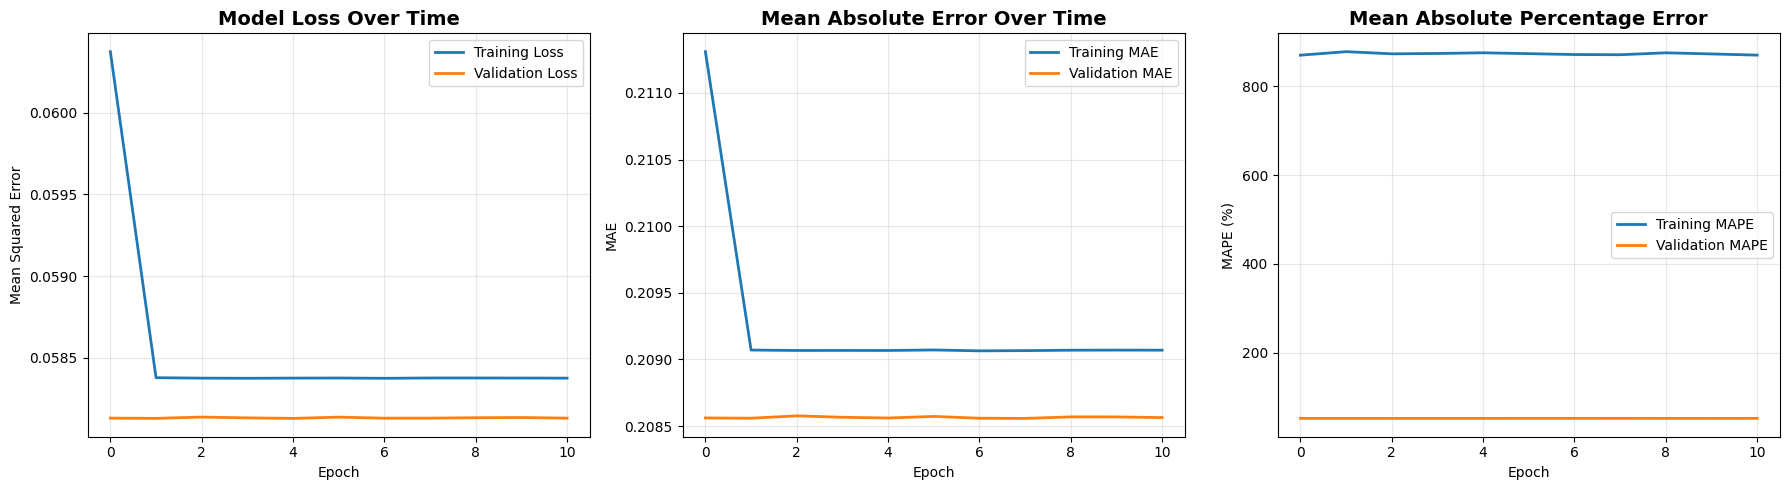

In [32]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Visualize training history for Simple RNN
    """

    print("=== TRAINING HISTORY VISUALIZATION ===")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # MAPE plot
    axes[2].plot(history.history['mean_absolute_percentage_error'],
                label='Training MAPE', linewidth=2)
    axes[2].plot(history.history['val_mean_absolute_percentage_error'],
                label='Validation MAPE', linewidth=2)
    axes[2].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(training_history)

#### 1.6.2 Model Performance Evaluation

In [33]:
def evaluate_simple_rnn_performance(model, X_test, y_test, target_scaler):
    """
    Comprehensive evaluation of Simple RNN performance
    """

    print("=== SIMPLE RNN MODEL EVALUATION ===")

    # Make predictions
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)

    # Calculate MAPE manually
    mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

    # Temperature-specific accuracy (within certain degrees)
    accuracy_1deg = np.mean(np.abs(y_test_original - y_pred_original) <= 1.0) * 100
    accuracy_2deg = np.mean(np.abs(y_test_original - y_pred_original) <= 2.0) * 100
    accuracy_3deg = np.mean(np.abs(y_test_original - y_pred_original) <= 3.0) * 100

    # Print results
    print("\n🌤️  SIMPLE RNN WEATHER PREDICTION RESULTS 🌤️")
    print("=" * 55)
    print(f"📊 Mean Squared Error (MSE):      {mse:.4f}")
    print(f"📊 Root Mean Squared Error (RMSE): {rmse:.4f}°C")
    print(f"📊 Mean Absolute Error (MAE):     {mae:.4f}°C")
    print(f"📊 R-squared Score (R²):          {r2:.4f}")
    print(f"📊 Mean Absolute Percentage Error: {mape:.2f}%")
    print("=" * 55)
    print("🎯 TEMPERATURE PREDICTION ACCURACY:")
    print(f"   Within ±1°C: {accuracy_1deg:.1f}% of predictions")
    print(f"   Within ±2°C: {accuracy_2deg:.1f}% of predictions")
    print(f"   Within ±3°C: {accuracy_3deg:.1f}% of predictions")
    print("=" * 55)

    return {
        'y_true': y_test_original,
        'y_pred': y_pred_original,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape,
        'accuracy_1deg': accuracy_1deg,
        'accuracy_2deg': accuracy_2deg,
        'accuracy_3deg': accuracy_3deg
    }

# Evaluate the model
evaluation_results = evaluate_simple_rnn_performance(model, X_test, y_test, target_scaler)

=== SIMPLE RNN MODEL EVALUATION ===

🌤️  SIMPLE RNN WEATHER PREDICTION RESULTS 🌤️
📊 Mean Squared Error (MSE):      210.3260
📊 Root Mean Squared Error (RMSE): 14.5026°C
📊 Mean Absolute Error (MAE):     12.5484°C
📊 R-squared Score (R²):          -0.0001
📊 Mean Absolute Percentage Error: 976.06%
🎯 TEMPERATURE PREDICTION ACCURACY:
   Within ±1°C: 4.0% of predictions
   Within ±2°C: 7.9% of predictions
   Within ±3°C: 11.9% of predictions


#### 1.6.3 Prediction Visualization

=== PREDICTION VISUALIZATION ===


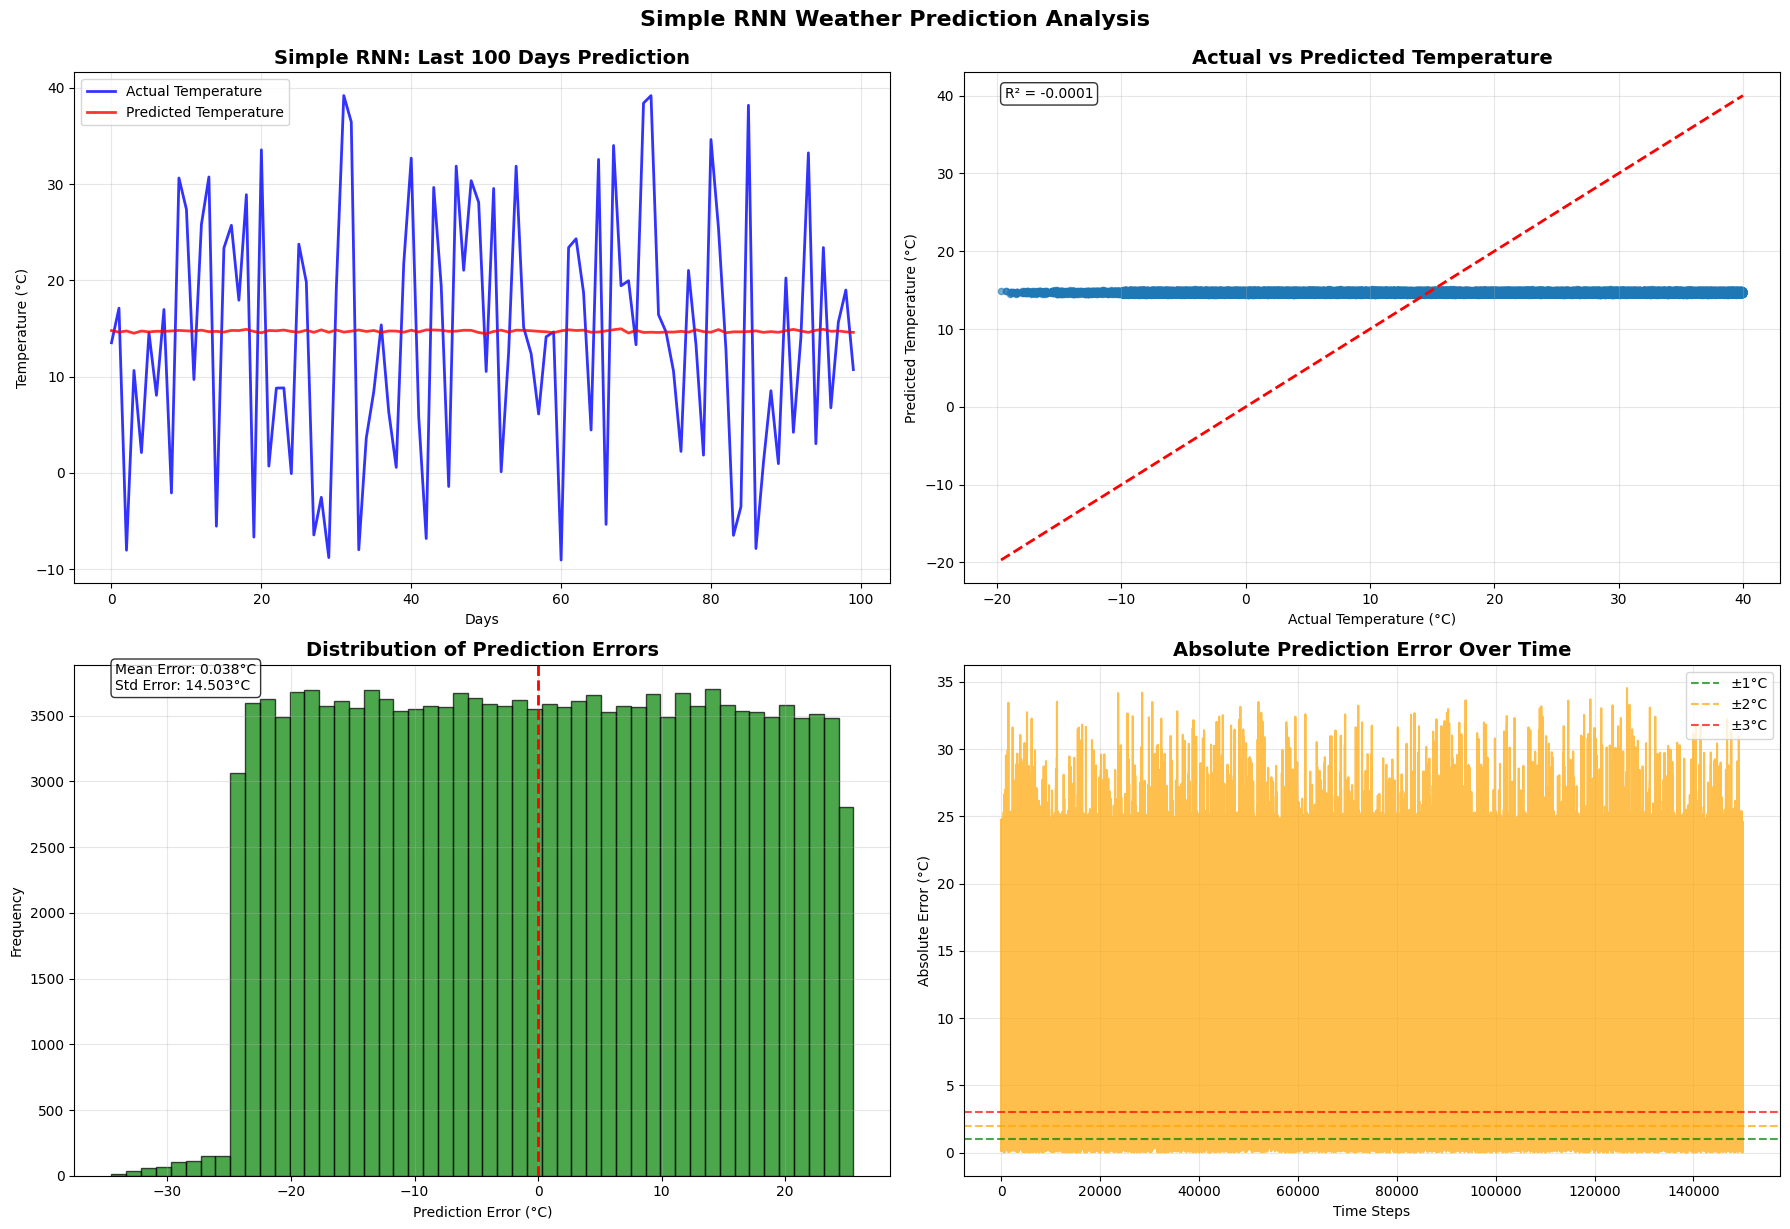

In [34]:
def visualize_predictions(results, days_to_show=100):
    """
    Create comprehensive visualizations of Simple RNN predictions
    """

    print(f"=== PREDICTION VISUALIZATION ===")

    y_true = results['y_true']
    y_pred = results['y_pred']

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Time series plot (last N days)
    axes[0, 0].plot(y_true[-days_to_show:], label='Actual Temperature',
                   linewidth=2, alpha=0.8, color='blue')
    axes[0, 0].plot(y_pred[-days_to_show:], label='Predicted Temperature',
                   linewidth=2, alpha=0.8, color='red')
    axes[0, 0].set_title(f'Simple RNN: Last {days_to_show} Days Prediction',
                        fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Days')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Scatter plot: Actual vs Predicted
    axes[0, 1].scatter(y_true, y_pred, alpha=0.6, s=20)
    min_temp, max_temp = y_true.min(), y_true.max()
    axes[0, 1].plot([min_temp, max_temp], [min_temp, max_temp], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Temperature (°C)')
    axes[0, 1].set_ylabel('Predicted Temperature (°C)')
    axes[0, 1].set_title('Actual vs Predicted Temperature', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # Add R² to scatter plot
    r2 = results['r2']
    axes[0, 1].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3. Error distribution
    errors = y_true - y_pred
    axes[1, 0].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Prediction Error (°C)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Add error statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    axes[1, 0].text(0.05, 0.95, f'Mean Error: {mean_error:.3f}°C\nStd Error: {std_error:.3f}°C',
                   transform=axes[1, 0].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Error over time
    axes[1, 1].plot(np.abs(errors), alpha=0.7, color='orange')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Absolute Error (°C)')
    axes[1, 1].set_title('Absolute Prediction Error Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    # Add horizontal lines for accuracy thresholds
    axes[1, 1].axhline(1, color='green', linestyle='--', alpha=0.7, label='±1°C')
    axes[1, 1].axhline(2, color='orange', linestyle='--', alpha=0.7, label='±2°C')
    axes[1, 1].axhline(3, color='red', linestyle='--', alpha=0.7, label='±3°C')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.suptitle('Simple RNN Weather Prediction Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Visualize predictions
visualize_predictions(evaluation_results, days_to_show=100)


#### 1.6.4 Real-time Prediction Function

In [36]:
def make_weather_prediction(model, recent_data, feature_scaler, target_scaler,
                           feature_columns, sequence_length=5):
    """
    Make a weather prediction using the trained Simple RNN model
    """

    print(f"=== MAKING NEW WEATHER PREDICTION ===")

    if len(recent_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} days of recent data")

    # Keep only numeric features used in training
    recent_numeric = recent_data[feature_columns].iloc[-sequence_length:].copy()

    # Scale features
    recent_scaled = feature_scaler.transform(recent_numeric)

    # Reshape for model input: (1, sequence_length, features)
    input_seq = recent_scaled.reshape(1, sequence_length, -1)

    # Make prediction (scaled)
    pred_scaled = model.predict(input_seq, verbose=0)

    # Inverse transform to original scale
    pred = target_scaler.inverse_transform(pred_scaled)[0, 0]

    print(f"🌡️  Predicted temperature for tomorrow: {pred:.2f}°C")

    return pred


In [37]:
df_clean.tail(5)

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
999995,Dallas,2024-01-01 20:29:48,23.416877,37.705024,3.819833,16.538119
999996,San Antonio,2024-01-20 15:59:48,6.759080,40.731036,8.182785,29.005558
999997,New York,2024-04-14 08:30:09,15.664465,62.201884,3.987558,0.403909
999998,Chicago,2024-05-12 20:10:43,18.999994,63.703245,4.294325,6.326036
999999,New York,2024-04-16 16:11:52,10.725351,43.804584,1.883292,15.363828


In [39]:
print(f"Actual Temperature value of last data: {df_clean.tail(5)['Temperature_C'].values[-1]}")


Actual Temperature value of last data: 10.725351075421568


### Understanding Simple RNN Limitations

In [40]:
def analyze_simple_rnn_limitations():
    """
    Educational analysis of Simple RNN limitations for students
    """

    print("=== UNDERSTANDING SIMPLE RNN LIMITATIONS ===")
    print("\n🧠 WHY SIMPLE RNN HAS LIMITATIONS:")
    print("=" * 50)

    print("1. 📉 VANISHING GRADIENT PROBLEM:")
    print("   - Gradients become very small as they propagate back through time")
    print("   - Model struggles to learn from events more than 5-10 time steps ago")
    print("   - Weather patterns often require longer memory (weeks/months)")

    print("\n2. 🔄 SHORT-TERM MEMORY:")
    print("   - Simple RNN forgets information from distant past quickly")
    print("   - Weather has seasonal patterns that need long-term memory")
    print("   - Best performance with 3-7 day sequences")

    print("\n3. 🎯 PERFORMANCE COMPARISON:")
    print("   - Simple RNN: Good for short-term patterns")
    print("   - LSTM/GRU: Better for long-term dependencies")
    print("   - Complex weather patterns need advanced models")

    print("\n💡 WHEN TO USE SIMPLE RNN:")
    print("   ✅ Learning RNN fundamentals")
    print("   ✅ Short-term predictions (1-3 days)")
    print("   ✅ Simple patterns and trends")
    print("   ✅ Computational resource constraints")
    print("   ✅ Proof of concept projects")

    print("\n🚀 NEXT STEPS FOR STUDENTS:")
    print("   1. Master Simple RNN concepts")
    print("   2. Learn LSTM architecture")
    print("   3. Compare performance differences")
    print("   4. Understand when to use each model")
    print("=" * 50)

# Run the educational analysis
analyze_simple_rnn_limitations()

=== UNDERSTANDING SIMPLE RNN LIMITATIONS ===

🧠 WHY SIMPLE RNN HAS LIMITATIONS:
1. 📉 VANISHING GRADIENT PROBLEM:
   - Gradients become very small as they propagate back through time
   - Model struggles to learn from events more than 5-10 time steps ago
   - Weather patterns often require longer memory (weeks/months)

2. 🔄 SHORT-TERM MEMORY:
   - Simple RNN forgets information from distant past quickly
   - Weather has seasonal patterns that need long-term memory
   - Best performance with 3-7 day sequences

3. 🎯 PERFORMANCE COMPARISON:
   - Simple RNN: Good for short-term patterns
   - LSTM/GRU: Better for long-term dependencies
   - Complex weather patterns need advanced models

💡 WHEN TO USE SIMPLE RNN:
   ✅ Learning RNN fundamentals
   ✅ Short-term predictions (1-3 days)
   ✅ Simple patterns and trends
   ✅ Computational resource constraints
   ✅ Proof of concept projects

🚀 NEXT STEPS FOR STUDENTS:
   1. Master Simple RNN concepts
   2. Learn LSTM architecture
   3. Compare perfor

### Exercises

In [ ]:
def student_exercises():
    """
    Hands-on exercises for students to reinforce learning
    """

    print("📚 STUDENT EXERCISES - SIMPLE RNN WEATHER PREDICTION")
    print("=" * 60)

    exercises = [
        {
            "title": "Exercise 1: Experiment with Sequence Length",
            "description": "Try different sequence lengths (3, 5, 7, 10) and observe performance changes",
            "code_hint": "modify sequence_length parameter in prepare_data_for_simple_rnn()",
            "expected_outcome": "Understand how sequence length affects Simple RNN performance"
        },
        {
            "title": "Exercise 2: Change Hidden Units",
            "description": "Test different hidden layer sizes (16, 32, 64, 128)",
            "code_hint": "modify hidden_units parameter in create_simple_rnn_model()",
            "expected_outcome": "Learn about model capacity and overfitting"
        },
        {
            "title": "Exercise 3: Feature Selection",
            "description": "Try using different combinations of weather features",
            "code_hint": "modify feature_columns list before training",
            "expected_outcome": "Understand which features are most important for prediction"
        },
        {
            "title": "Exercise 4: Predict Different Variables",
            "description": "Try predicting humidity or wind speed instead of temperature",
            "code_hint": "change target_column parameter to 'Relative_Humidity' or 'Wind_Speed'",
            "expected_outcome": "See how model performs on different weather variables"
        },
        {
            "title": "Exercise 5: Error Analysis",
            "description": "Identify when the model makes the largest errors",
            "code_hint": "analyze prediction errors by season or weather conditions",
            "expected_outcome": "Understand model limitations and failure cases"
        }
    ]

    for i, exercise in enumerate(exercises, 1):
        print(f"\n🎯 {exercise['title']}")
        print(f"   Task: {exercise['description']}")
        print(f"   Hint: {exercise['code_hint']}")
        print(f"   Goal: {exercise['expected_outcome']}")

    print("\n" + "=" * 60)
    print(" Remember: Simple RNN is a stepping stone to advanced models!")

# Display exercises
student_exercises()


📚 STUDENT EXERCISES - SIMPLE RNN WEATHER PREDICTION

🎯 Exercise 1: Experiment with Sequence Length
   📝 Task: Try different sequence lengths (3, 5, 7, 10) and observe performance changes
   💡 Hint: modify sequence_length parameter in prepare_data_for_simple_rnn()
   🎯 Goal: Understand how sequence length affects Simple RNN performance

🎯 Exercise 2: Change Hidden Units
   📝 Task: Test different hidden layer sizes (16, 32, 64, 128)
   💡 Hint: modify hidden_units parameter in create_simple_rnn_model()
   🎯 Goal: Learn about model capacity and overfitting

🎯 Exercise 3: Feature Selection
   📝 Task: Try using different combinations of weather features
   💡 Hint: modify feature_columns list before training
   🎯 Goal: Understand which features are most important for prediction

🎯 Exercise 4: Predict Different Variables
   📝 Task: Try predicting humidity or wind speed instead of temperature
   💡 Hint: change target_column parameter to 'Relative_Humidity' or 'Wind_Speed'
   🎯 Goal: See how mod

## **Exercise 1: Experimenting with Sequence Length**

**Goal**: Testing different sequence lengths (3, 5, 7, 10) and observing performance changes

1. Using `SEQUENCE_LENGTH = 5`
2. Testing with different values and comparing results


In [51]:
def test_sequence_lengths(sequence_lengths=[3, 5, 7, 10]):
    """
    Test different sequence lengths and compare performance
    """
    results = {}
    
    for seq_len in sequence_lengths:
        print(f"\n{'='*50}")
        print(f"Testing Sequence Length: {seq_len}")
        print(f"{'='*50}")
        
        # Use correct column names from your data
        feature_columns_correct = ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
        target_column_correct = 'Temperature_C'
        
        # Prepare data with current sequence length
        (X_train_temp, y_train_temp), (X_val_temp, y_val_temp), (X_test_temp, y_test_temp) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            feature_columns_correct, target_column_correct,  # Use correct names
            feature_scaler, target_scaler,
            sequence_length=seq_len
        )
        
        # Create model
        input_shape_temp = (X_train_temp.shape[1], X_train_temp.shape[2])
        model_temp = create_simple_rnn_model(input_shape_temp, hidden_units=32, dropout_rate=0.2)
        
        # Train model (fewer epochs for comparison)
        history_temp = train_simple_rnn_model(
            model_temp, X_train_temp, y_train_temp, X_val_temp, y_val_temp,
            epochs=30, batch_size=32, patience=5  # Reduced for faster comparison
        )
        
        # Evaluate
        eval_results = evaluate_simple_rnn_performance(model_temp, X_test_temp, y_test_temp, target_scaler)
        
        # Store results
        results[seq_len] = {
            'rmse': eval_results['rmse'],
            'mae': eval_results['mae'],
            'r2': eval_results['r2'],
            'mape': eval_results['mape']
        }
        
        # Clean up
        del model_temp
        
    return results

print("Updated function created successfully! Ready to test sequence lengths.")

Updated function created successfully! Ready to test sequence lengths.


In [52]:
# First, let's check what columns we actually have
print("Available columns in train_data:")
print(train_data.columns.tolist())
print("\nData shape:", train_data.shape)
print("\nFirst few rows:")
print(train_data.head(2))

Available columns in train_data:
['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']

Data shape: (700000, 6)

First few rows:
    Location            Date_Time  Temperature_C  Humidity_pct  \
0  San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1  San Diego  2024-05-17 15:22:10       8.734140     58.319107   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  


In [53]:
# Run the test - this will take several minutes
print("Starting sequence length comparison...")
sequence_results = test_sequence_lengths([3, 5, 7, 10])
print("Testing completed!")

Starting sequence length comparison...

Testing Sequence Length: 3
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 3 days
Target: Temperature_C
Features (before filtering): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Features (numeric only): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699997, 3, 3)
Training targets: (699997,)
Validation sequences: (149997, 3, 3)
Test sequences: (149997, 3, 3)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (3, 3)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

...

=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699990
Validation samples: 149990
Epochs: 30
Batch size: 32

Starting training...
Epoch 1/30
21835/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0729 - mean_absolute_error: 0.2242 - mean_absolute_percentage_error: 590.7088
Epoch 1: val_loss improved from inf to 0.05814, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 16s 693us/step - loss: 0.0729 - mean_absolute_error: 0.2242 - mean_absolute_percentage_error: 591.2186 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7103
Epoch 2/30
21832/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 594.0419
Epoch 2: val_loss improved from 0.05814 to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 15s 689us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 594.5990 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7307
Epoch 3/30
21851/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.4232
Epoch 3: val_loss improved from 0.05813 to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 15s 687us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.7398 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7983
Epoch 4/30
21834/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.2477
Epoch 4: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 15s 687us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.7806 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7184
Epoch 5/30
21821/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.5183
Epoch 5: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 15s 688us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 596.2177 - val_lo

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 15s 689us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 597.5329 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7575
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Training completed!
=== SIMPLE RNN MODEL EVALUATION ===

🌤️  SIMPLE RNN WEATHER PREDICTION RESULTS 🌤️
📊 Mean Squared Error (MSE):      210.3357
📊 Root Mean Squared Error (RMSE): 14.5030°C
📊 Mean Absolute Error (MAE):     12.5481°C
📊 R-squared Score (R²):          -0.0001
📊 Mean Absolute Percentage Error: 973.41%
🎯 TEMPERATURE PREDICTION ACCURACY:
   Within ±1°C: 4.0% of predictions
   Within ±2°C: 8.0% of predictions
   Within ±3°C: 11.9% of predictions
Testing completed!


In [57]:
def analyze_sequence_length_results(results):
    """
    Analyze and visualize sequence length experiment results
    """
    # Convert to DataFrame for easy analysis
    df_results = pd.DataFrame(results).T
    
    print("\n SEQUENCE LENGTH COMPARISON RESULTS")
    print("="*50)
    print(df_results.round(4))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    metrics = ['rmse', 'mae', 'r2', 'mape']
    titles = ['RMSE (°C)', 'MAE (°C)', 'R² Score', 'MAPE (%)']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[i//2, i%2]
        sequence_lens = list(results.keys())
        values = [results[seq][metric] for seq in sequence_lens]
        
        ax.plot(sequence_lens, values, 'bo-', linewidth=2, markersize=8)
        ax.set_xlabel('Sequence Length')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs Sequence Length')
        ax.grid(True, alpha=0.3)
        
        # Mark the best value
        if metric == 'r2':  # Higher is better for R²
            best_idx = values.index(max(values))
        else:  # Lower is better for RMSE, MAE, MAPE
            best_idx = values.index(min(values))
        
        ax.plot(sequence_lens[best_idx], values[best_idx], 'ro', markersize=12, alpha=0.7)
    
    plt.tight_layout()
    plt.suptitle('Simple RNN Performance vs Sequence Length', fontsize=16, y=1.02)
    plt.show()
    
    # Find best sequence length
    best_seq_len = min(results.keys(), key=lambda x: results[x]['rmse'])
    print(f"\n Best Sequence Length: {best_seq_len} (lowest RMSE: {results[best_seq_len]['rmse']:.4f}°C)")
    
    return df_results

print("Analysis function created successfully!")

Analysis function created successfully!



 SEQUENCE LENGTH COMPARISON RESULTS
       rmse      mae      r2      mape
3   14.5030  12.5484 -0.0001  976.6634
5   14.5041  12.5491 -0.0003  971.3517
7   14.5032  12.5485 -0.0001  970.0414
10  14.5030  12.5481 -0.0001  973.4094


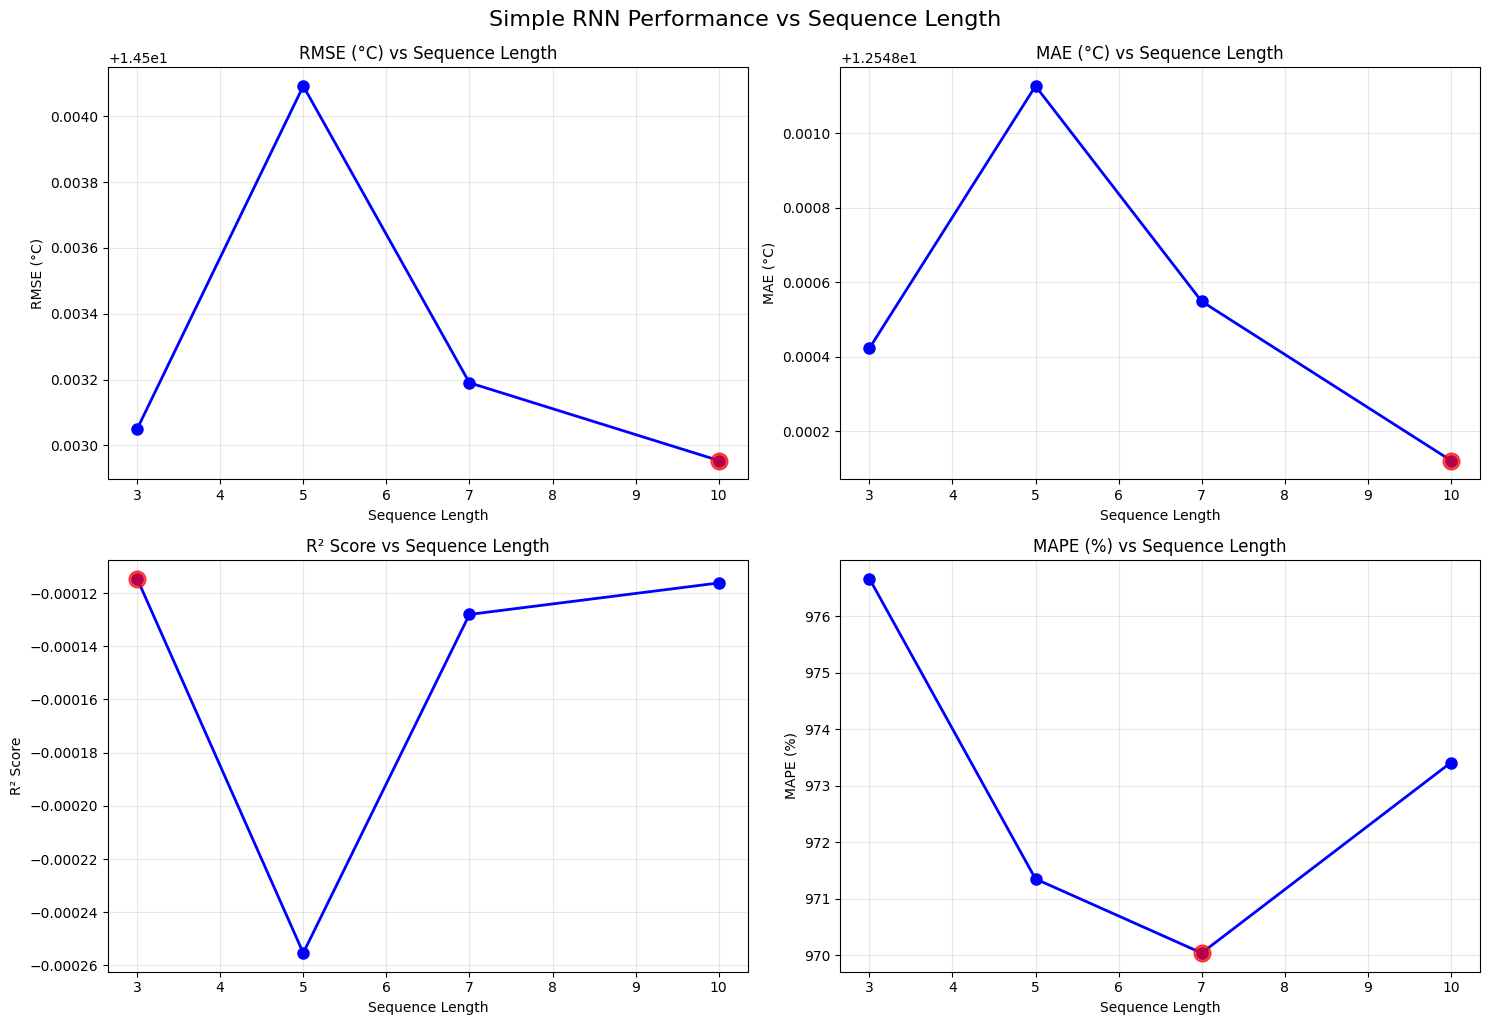


 Best Sequence Length: 10 (lowest RMSE: 14.5030°C)


In [58]:
# Analyze results
df_comparison = analyze_sequence_length_results(sequence_results)

In [59]:
# Additional insights
print("\n DETAILED ANALYSIS:")
print("="*40)

for seq_len, metrics in sequence_results.items():
    print(f"\nSequence Length {seq_len}:")
    print(f"  RMSE: {metrics['rmse']:.4f}°C")
    print(f"  MAE:  {metrics['mae']:.4f}°C") 
    print(f"  R²:   {metrics['r2']:.4f}")
    print(f"  MAPE: {metrics['mape']:.2f}%")


 DETAILED ANALYSIS:

Sequence Length 3:
  RMSE: 14.5030°C
  MAE:  12.5484°C
  R²:   -0.0001
  MAPE: 976.66%

Sequence Length 5:
  RMSE: 14.5041°C
  MAE:  12.5491°C
  R²:   -0.0003
  MAPE: 971.35%

Sequence Length 7:
  RMSE: 14.5032°C
  MAE:  12.5485°C
  R²:   -0.0001
  MAPE: 970.04%

Sequence Length 10:
  RMSE: 14.5030°C
  MAE:  12.5481°C
  R²:   -0.0001
  MAPE: 973.41%


In [60]:
# Let's examine the data relationships
print("Data correlation with temperature:")
correlation_with_temp = train_data[['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']].corr()['Temperature_C']
print(correlation_with_temp)

print("\nTemperature statistics:")
print(train_data['Temperature_C'].describe())

print("\nSample of actual vs scaled values:")
print(f"Original temp range: {train_data['Temperature_C'].min():.2f} to {train_data['Temperature_C'].max():.2f}")

Data correlation with temperature:
Temperature_C       1.000000
Humidity_pct       -0.002068
Precipitation_mm   -0.010103
Wind_Speed_kmh     -0.001015
Name: Temperature_C, dtype: float64

Temperature statistics:
count    700000.000000
mean         14.780082
std          14.483582
min         -19.969311
25%           2.272707
50%          14.766472
75%          27.261806
max          39.999692
Name: Temperature_C, dtype: float64

Sample of actual vs scaled values:
Original temp range: -19.97 to 40.00


## **Exercise 2: Experimenting with Hidden Units**

**Goal**: Testing different hidden layer sizes (16, 32, 64, 128) and observing performance changes

1. Using `hidden_units=32`
2. Testing with different values and comparing results



### **Creating the testing function for hidden units**


In [62]:
def test_hidden_units(hidden_units_list=[16, 32, 64, 128]):
    """
    Test different hidden unit sizes and compare performance
    """
    results = {}
    
    # Use the best sequence length from Exercise 1 (or stick with 5)
    best_sequence_length = 5
    
    for hidden_units in hidden_units_list:
        print(f"\n{'='*50}")
        print(f"Testing Hidden Units: {hidden_units}")
        print(f"{'='*50}")
        
        # Use the same data preparation as before
        feature_columns_correct = ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
        target_column_correct = 'Temperature_C'
        
        # Prepare data with fixed sequence length
        (X_train_temp, y_train_temp), (X_val_temp, y_val_temp), (X_test_temp, y_test_temp) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            feature_columns_correct, target_column_correct,
            feature_scaler, target_scaler,
            sequence_length=best_sequence_length
        )
        
        # Create model with different hidden units
        input_shape_temp = (X_train_temp.shape[1], X_train_temp.shape[2])
        model_temp = create_simple_rnn_model(input_shape_temp, hidden_units=hidden_units, dropout_rate=0.2)
        
        # Train model (fewer epochs for comparison)
        history_temp = train_simple_rnn_model(
            model_temp, X_train_temp, y_train_temp, X_val_temp, y_val_temp,
            epochs=30, batch_size=32, patience=5
        )
        
        # Evaluate
        eval_results = evaluate_simple_rnn_performance(model_temp, X_test_temp, y_test_temp, target_scaler)
        
        # Store results
        results[hidden_units] = {
            'rmse': eval_results['rmse'],
            'mae': eval_results['mae'],
            'r2': eval_results['r2'],
            'mape': eval_results['mape'],
            'total_params': model_temp.count_params()
        }
        
        # Clean up
        del model_temp
        
    return results

print("Hidden units testing function created successfully!")

Hidden units testing function created successfully!


### **Running the hidden units test**

In [63]:
# Run the test 
print("Starting hidden units comparison...")
hidden_units_results = test_hidden_units([16, 32, 64, 128])
print("Testing completed!")


Starting hidden units comparison...

Testing Hidden Units: 16
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature_C
Features (before filtering): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Features (numeric only): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699995, 5, 3)
Training targets: (699995,)
Validation sequences: (149995, 5, 3)
Test sequences: (149995, 5, 3)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 3)
Hidden units: 16
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

...

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699995
Validation samples: 149995
Epochs: 30
Batch size: 32

Starting training...
Epoch 1/30
21856/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.0637 - mean_absolute_error: 0.2152 - mean_absolute_percentage_error: 611.3843
Epoch 1: val_loss improved from inf to 0.05814, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 16s 725us/step - loss: 0.0637 - mean_absolute_error: 0.2152 - mean_absolute_percentage_error: 611.6439 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.6095
Epoch 2/30
21804/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.4153
Epoch 2: val_loss improved from 0.05814 to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 16s 724us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 599.3379 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7828
Epoch 3/30
21847/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.6041
Epoch 3: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 16s 718us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.9736 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7433
Epoch 4/30
21851/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 597.8248
Epoch 4: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 16s 719us/step - loss: 0.0584 - mean_absolute_error: 0.2092 - mean_absolute_percentage_error: 598.1428 - val_lo

### **Creating the analysis function for hidden units**

In [68]:
def analyze_hidden_units_results(results):
    """
    Analyze and visualize hidden units experiment results
    """
    # Convert to DataFrame for easy analysis
    df_results = pd.DataFrame(results).T
    
    print("\n HIDDEN UNITS COMPARISON RESULTS")
    print("="*50)
    print(df_results.round(4))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = ['rmse', 'mae', 'r2', 'mape', 'total_params']
    titles = ['RMSE (°C)', 'MAE (°C)', 'R² Score', 'MAPE (%)', 'Total Parameters']
    
    for i, (metric, title) in enumerate(zip(metrics, titles)):
        if i < 5:  # We have 5 metrics
            ax = axes[i//3, i%3]
            hidden_units = list(results.keys())
            values = [results[hu][metric] for hu in hidden_units]
            
            ax.plot(hidden_units, values, 'go-', linewidth=2, markersize=8)
            ax.set_xlabel('Hidden Units')
            ax.set_ylabel(title)
            ax.set_title(f'{title} vs Hidden Units')
            ax.grid(True, alpha=0.3)
            
            # Mark the best value (except for total_params)
            if metric != 'total_params':
                if metric == 'r2':  # Higher is better for R²
                    best_idx = values.index(max(values))
                else:  # Lower is better for RMSE, MAE, MAPE
                    best_idx = values.index(min(values))
                
                ax.plot(hidden_units[best_idx], values[best_idx], 'ro', markersize=12, alpha=0.7)
    
    # Remove the 6th subplot (we only have 5 metrics)
    axes[1, 2].remove()
    
    plt.tight_layout()
    plt.suptitle('Simple RNN Performance vs Hidden Units', fontsize=16, y=1.02)
    plt.show()
    
    # Find best hidden unit size
    best_hidden_units = min(results.keys(), key=lambda x: results[x]['rmse'])
    print(f"\n🏆 Best Hidden Units: {best_hidden_units} (lowest RMSE: {results[best_hidden_units]['rmse']:.4f}°C)")
    
    # Model complexity analysis
    print(f"\n🔧 MODEL COMPLEXITY ANALYSIS:")
    for hu in sorted(results.keys()):
        params = results[hu]['total_params']
        rmse = results[hu]['rmse']
        print(f"   {hu} units: {params:,} parameters, RMSE: {rmse:.4f}°C")
    
    return df_results

print("Hidden units analysis function created successfully!")

Hidden units analysis function created successfully!


### **Analyzing and visualizing hidden units results**



 HIDDEN UNITS COMPARISON RESULTS
        rmse      mae      r2      mape  total_params
16   14.5024  12.5482 -0.0000  977.5635         337.0
32   14.5030  12.5486 -0.0001  974.6353        1185.0
64   14.5030  12.5485 -0.0001  970.2137        4417.0
128  14.5046  12.5496 -0.0003  969.9545       17025.0


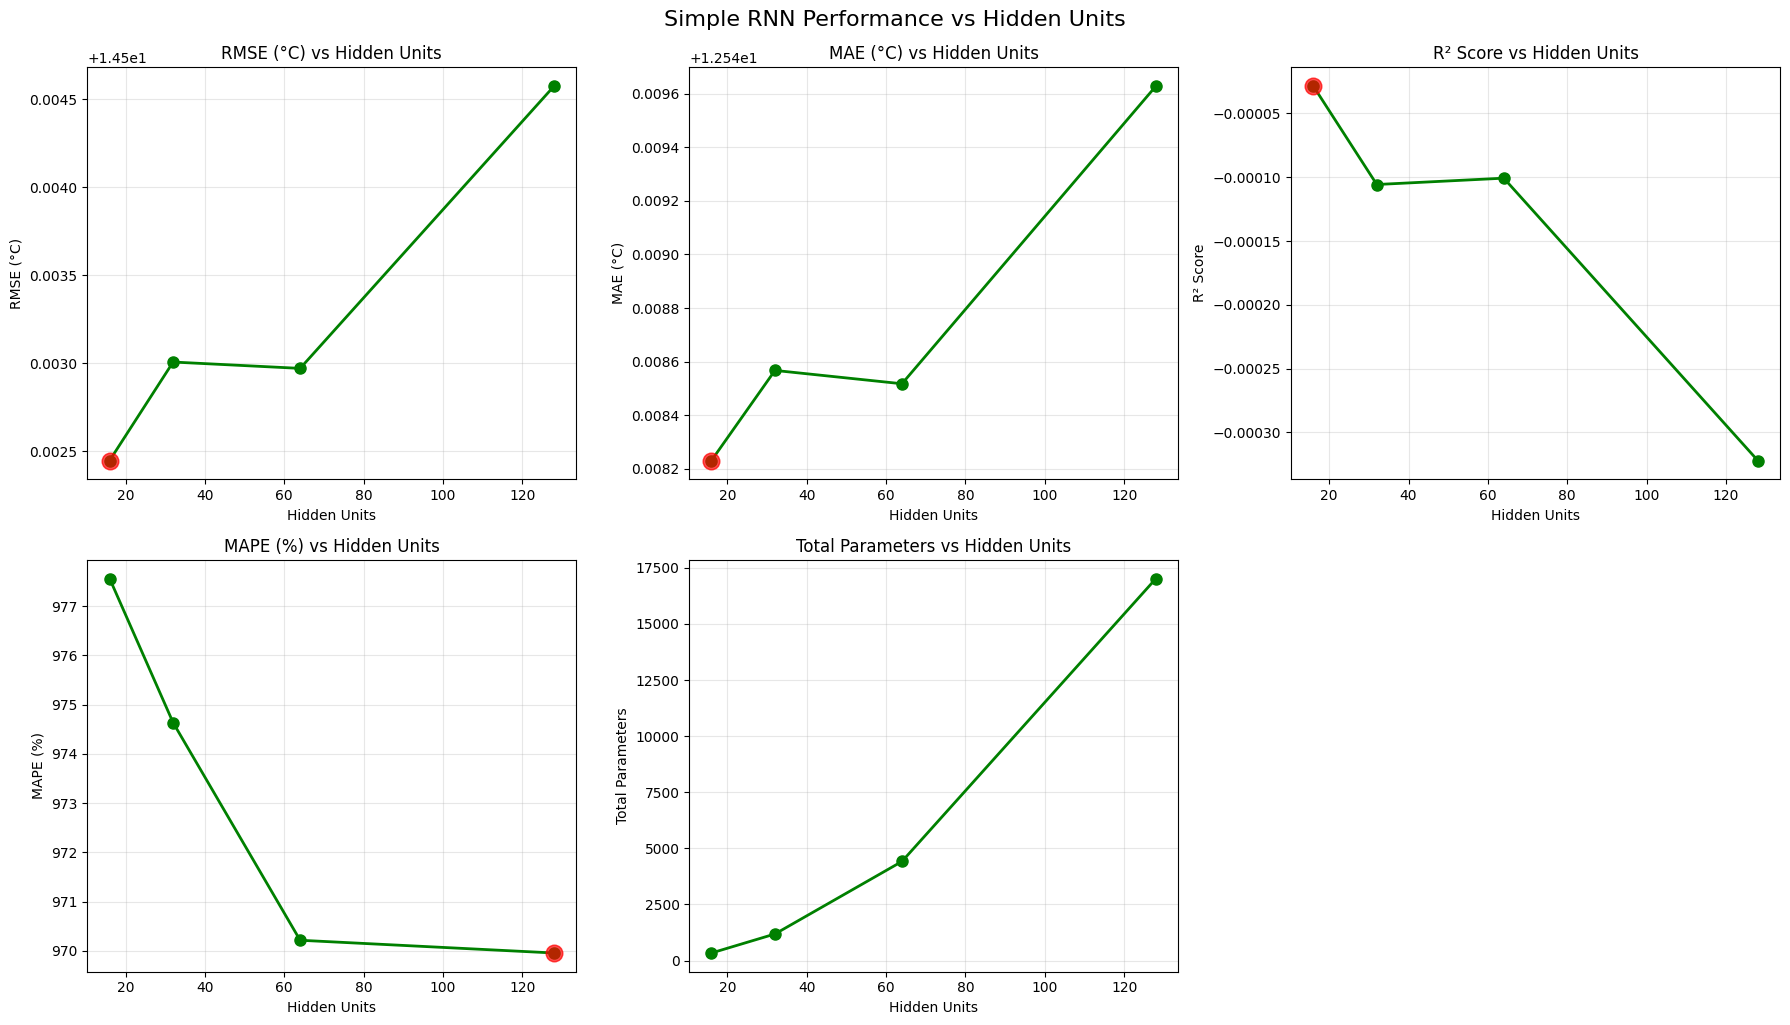


🏆 Best Hidden Units: 16 (lowest RMSE: 14.5024°C)

🔧 MODEL COMPLEXITY ANALYSIS:
   16 units: 337 parameters, RMSE: 14.5024°C
   32 units: 1,185 parameters, RMSE: 14.5030°C
   64 units: 4,417 parameters, RMSE: 14.5030°C
   128 units: 17,025 parameters, RMSE: 14.5046°C


In [69]:
# Analyze results
df_hidden_comparison = analyze_hidden_units_results(hidden_units_results)

### **Additional detailed analysis for hidden units**


In [67]:
print("\n DETAILED HIDDEN UNITS ANALYSIS:")
print("="*50)

for hidden_units, metrics in hidden_units_results.items():
    print(f"\nHidden Units {hidden_units}:")
    print(f"  RMSE: {metrics['rmse']:.4f}°C")
    print(f"  MAE:  {metrics['mae']:.4f}°C") 
    print(f"  R²:   {metrics['r2']:.4f}")
    print(f"  MAPE: {metrics['mape']:.2f}%")
    print(f"  Parameters: {metrics['total_params']:,}")

# Calculate parameter efficiency
print(f"\n PARAMETER EFFICIENCY ANALYSIS:")
print("="*50)
for hidden_units in sorted(hidden_units_results.keys()):
    rmse = hidden_units_results[hidden_units]['rmse']
    params = hidden_units_results[hidden_units]['total_params']
    efficiency = params / rmse if rmse > 0 else float('inf')
    print(f"  {hidden_units} units: {efficiency:.0f} parameters per RMSE point")


 DETAILED HIDDEN UNITS ANALYSIS:

Hidden Units 16:
  RMSE: 14.5024°C
  MAE:  12.5482°C
  R²:   -0.0000
  MAPE: 977.56%
  Parameters: 337

Hidden Units 32:
  RMSE: 14.5030°C
  MAE:  12.5486°C
  R²:   -0.0001
  MAPE: 974.64%
  Parameters: 1,185

Hidden Units 64:
  RMSE: 14.5030°C
  MAE:  12.5485°C
  R²:   -0.0001
  MAPE: 970.21%
  Parameters: 4,417

Hidden Units 128:
  RMSE: 14.5046°C
  MAE:  12.5496°C
  R²:   -0.0003
  MAPE: 969.95%
  Parameters: 17,025

 PARAMETER EFFICIENCY ANALYSIS:
  16 units: 23 parameters per RMSE point
  32 units: 82 parameters per RMSE point
  64 units: 305 parameters per RMSE point
  128 units: 1174 parameters per RMSE point


# **Exercise 3: Experimenting with Feature Selection**

**Goal**: Testing different combinations of weather features and observing performance changes

1. Using all 3 features: ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
2. Testing individual features and combinations to find the most predictive ones

**Feature combinations to test**:
- Individual features: Humidity only, Precipitation only, Wind Speed only
- Pairs: Humidity + Precipitation, Humidity + Wind Speed, Precipitation + Wind Speed
- All three features (baseline)

**Expected observations**:
- Some features may be more predictive than others
- Feature combinations might perform better than individual features
- Understanding which weather variables are most important for temperature prediction

### **Creating the testing function for feature combinations**


In [70]:
def test_feature_combinations():
    """
    Test different feature combinations and compare performance
    """
    results = {}
    
    # Define different feature combinations to test
    feature_combinations = {
        'Humidity_only': ['Humidity_pct'],
        'Precipitation_only': ['Precipitation_mm'],
        'Wind_Speed_only': ['Wind_Speed_kmh'],
        'Humidity_Precipitation': ['Humidity_pct', 'Precipitation_mm'],
        'Humidity_WindSpeed': ['Humidity_pct', 'Wind_Speed_kmh'],
        'Precipitation_WindSpeed': ['Precipitation_mm', 'Wind_Speed_kmh'],
        'All_features': ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
    }
    
    # Use best settings from previous exercises
    best_sequence_length = 5
    best_hidden_units = 32
    target_column_correct = 'Temperature_C'
    
    for combo_name, features in feature_combinations.items():
        print(f"\n{'='*60}")
        print(f"Testing Feature Combination: {combo_name}")
        print(f"Features: {features}")
        print(f"{'='*60}")
        
        # Prepare data with current feature combination
        (X_train_temp, y_train_temp), (X_val_temp, y_val_temp), (X_test_temp, y_test_temp) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            features, target_column_correct,
            feature_scaler, target_scaler,
            sequence_length=best_sequence_length
        )
        
        # Create model
        input_shape_temp = (X_train_temp.shape[1], X_train_temp.shape[2])
        model_temp = create_simple_rnn_model(input_shape_temp, hidden_units=best_hidden_units, dropout_rate=0.2)
        
        # Train model (fewer epochs for comparison)
        history_temp = train_simple_rnn_model(
            model_temp, X_train_temp, y_train_temp, X_val_temp, y_val_temp,
            epochs=20, batch_size=32, patience=5  # Reduced epochs for faster testing
        )
        
        # Evaluate
        eval_results = evaluate_simple_rnn_performance(model_temp, X_test_temp, y_test_temp, target_scaler)
        
        # Store results
        results[combo_name] = {
            'features': features,
            'num_features': len(features),
            'rmse': eval_results['rmse'],
            'mae': eval_results['mae'],
            'r2': eval_results['r2'],
            'mape': eval_results['mape'],
            'total_params': model_temp.count_params()
        }
        
        # Clean up
        del model_temp
        
    return results

print("Feature combination testing function created successfully!")

Feature combination testing function created successfully!


### **Running the feature combination test**


In [71]:
# Run the test 
print("Starting feature combination comparison...")
feature_results = test_feature_combinations()
print("Testing completed!")

Starting feature combination comparison...

Testing Feature Combination: Humidity_only
Features: ['Humidity_pct']
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature_C
Features (before filtering): ['Humidity_pct']
Features (numeric only): ['Humidity_pct']
Train Target : (700000,)
Training sequences: (699995, 5, 1)
Training targets: (699995,)
Validation sequences: (149995, 5, 1)
Test sequences: (149995, 5, 1)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 1)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

...

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699995
Validation samples: 149995
Epochs: 20
Batch size: 32

Starting training...
Epoch 1/20
21817/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.0690 - mean_absolute_error: 0.2204 - mean_absolute_percentage_error: 596.8326
Epoch 1: val_loss improved from inf to 0.05813, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 13s 548us/step - loss: 0.0690 - mean_absolute_error: 0.2203 - mean_absolute_percentage_error: 597.5789 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7291
Epoch 2/20
21788/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 594.7744
Epoch 2: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 542us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.8970 - val_loss: 0.0581 - val_mean_absolute_error: 0.2086 - val_mean_absolute_percentage_error: 51.7812
Epoch 3/20
21827/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 594.4098
Epoch 3: val_loss did not improve from 0.05813
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 544us/step - loss: 0.0584 - mean_absolute_error: 0.2091 - mean_absolute_percentage_error: 595.0311 - val_lo

### **Creating the analysis function for feature combinations**

In [74]:
def analyze_feature_combinations_results(results):
    """
    Analyze and visualize feature combination experiment results
    """
    # Convert to DataFrame for easy analysis
    df_results = pd.DataFrame(results).T
    
    print("\n FEATURE COMBINATION COMPARISON RESULTS")
    print("="*70)
    print(df_results[['num_features', 'rmse', 'mae', 'r2', 'mape']].round(4))
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    combo_names = list(results.keys())
    
    # 1. RMSE comparison
    rmse_values = [results[combo]['rmse'] for combo in combo_names]
    axes[0, 0].bar(range(len(combo_names)), rmse_values, color='lightblue', edgecolor='navy')
    axes[0, 0].set_title('RMSE by Feature Combination', fontweight='bold')
    axes[0, 0].set_ylabel('RMSE (°C)')
    axes[0, 0].set_xticks(range(len(combo_names)))
    axes[0, 0].set_xticklabels(combo_names, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. MAE comparison
    mae_values = [results[combo]['mae'] for combo in combo_names]
    axes[0, 1].bar(range(len(combo_names)), mae_values, color='lightgreen', edgecolor='darkgreen')
    axes[0, 1].set_title('MAE by Feature Combination', fontweight='bold')
    axes[0, 1].set_ylabel('MAE (°C)')
    axes[0, 1].set_xticks(range(len(combo_names)))
    axes[0, 1].set_xticklabels(combo_names, rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. R² comparison
    r2_values = [results[combo]['r2'] for combo in combo_names]
    axes[1, 0].bar(range(len(combo_names)), r2_values, color='lightcoral', edgecolor='darkred')
    axes[1, 0].set_title('R² Score by Feature Combination', fontweight='bold')
    axes[1, 0].set_ylabel('R² Score')
    axes[1, 0].set_xticks(range(len(combo_names)))
    axes[1, 0].set_xticklabels(combo_names, rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Number of parameters vs performance
    num_features = [results[combo]['num_features'] for combo in combo_names]
    total_params = [results[combo]['total_params'] for combo in combo_names]
    axes[1, 1].scatter(num_features, rmse_values, s=total_params, alpha=0.6, color='purple')
    axes[1, 1].set_title('Features vs RMSE (bubble size = parameters)', fontweight='bold')
    axes[1, 1].set_xlabel('Number of Features')
    axes[1, 1].set_ylabel('RMSE (°C)')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add labels to bubbles
    for i, combo in enumerate(combo_names):
        axes[1, 1].annotate(combo.replace('_', '\n'), 
                           (num_features[i], rmse_values[i]), 
                           fontsize=8, ha='center')
    
    plt.tight_layout()
    plt.suptitle('Feature Combination Analysis', fontsize=16, y=1.02, fontweight='bold')
    plt.show()
    
    # Find best feature combination
    best_combo = min(results.keys(), key=lambda x: results[x]['rmse'])
    best_features = results[best_combo]['features']
    
    print(f"\n Best Feature Combination: {best_combo}")
    print(f"   Features: {best_features}")
    print(f"   RMSE: {results[best_combo]['rmse']:.4f}°C")
    print(f"   R²: {results[best_combo]['r2']:.4f}")
    
    return df_results

print("Feature combination analysis function created successfully!")

Feature combination analysis function created successfully!


### **Analyzing and visualizing feature combination results**



 FEATURE COMBINATION COMPARISON RESULTS
                        num_features       rmse        mae        r2  \
Humidity_only                      1   14.50423  12.549469 -0.000274   
Precipitation_only                 1  14.502321  12.548113 -0.000011   
Wind_Speed_only                    1  14.502639  12.548466 -0.000055   
Humidity_Precipitation             2  14.502579   12.54841 -0.000047   
Humidity_WindSpeed                 2  14.502754  12.548462 -0.000071   
Precipitation_WindSpeed            2  14.502441  12.548295 -0.000028   
All_features                       3  14.502706  12.548509 -0.000064   

                               mape  
Humidity_only            967.949154  
Precipitation_only       974.225118  
Wind_Speed_only          978.405783  
Humidity_Precipitation   974.219392  
Humidity_WindSpeed       972.354485  
Precipitation_WindSpeed  975.484285  
All_features             974.714729  


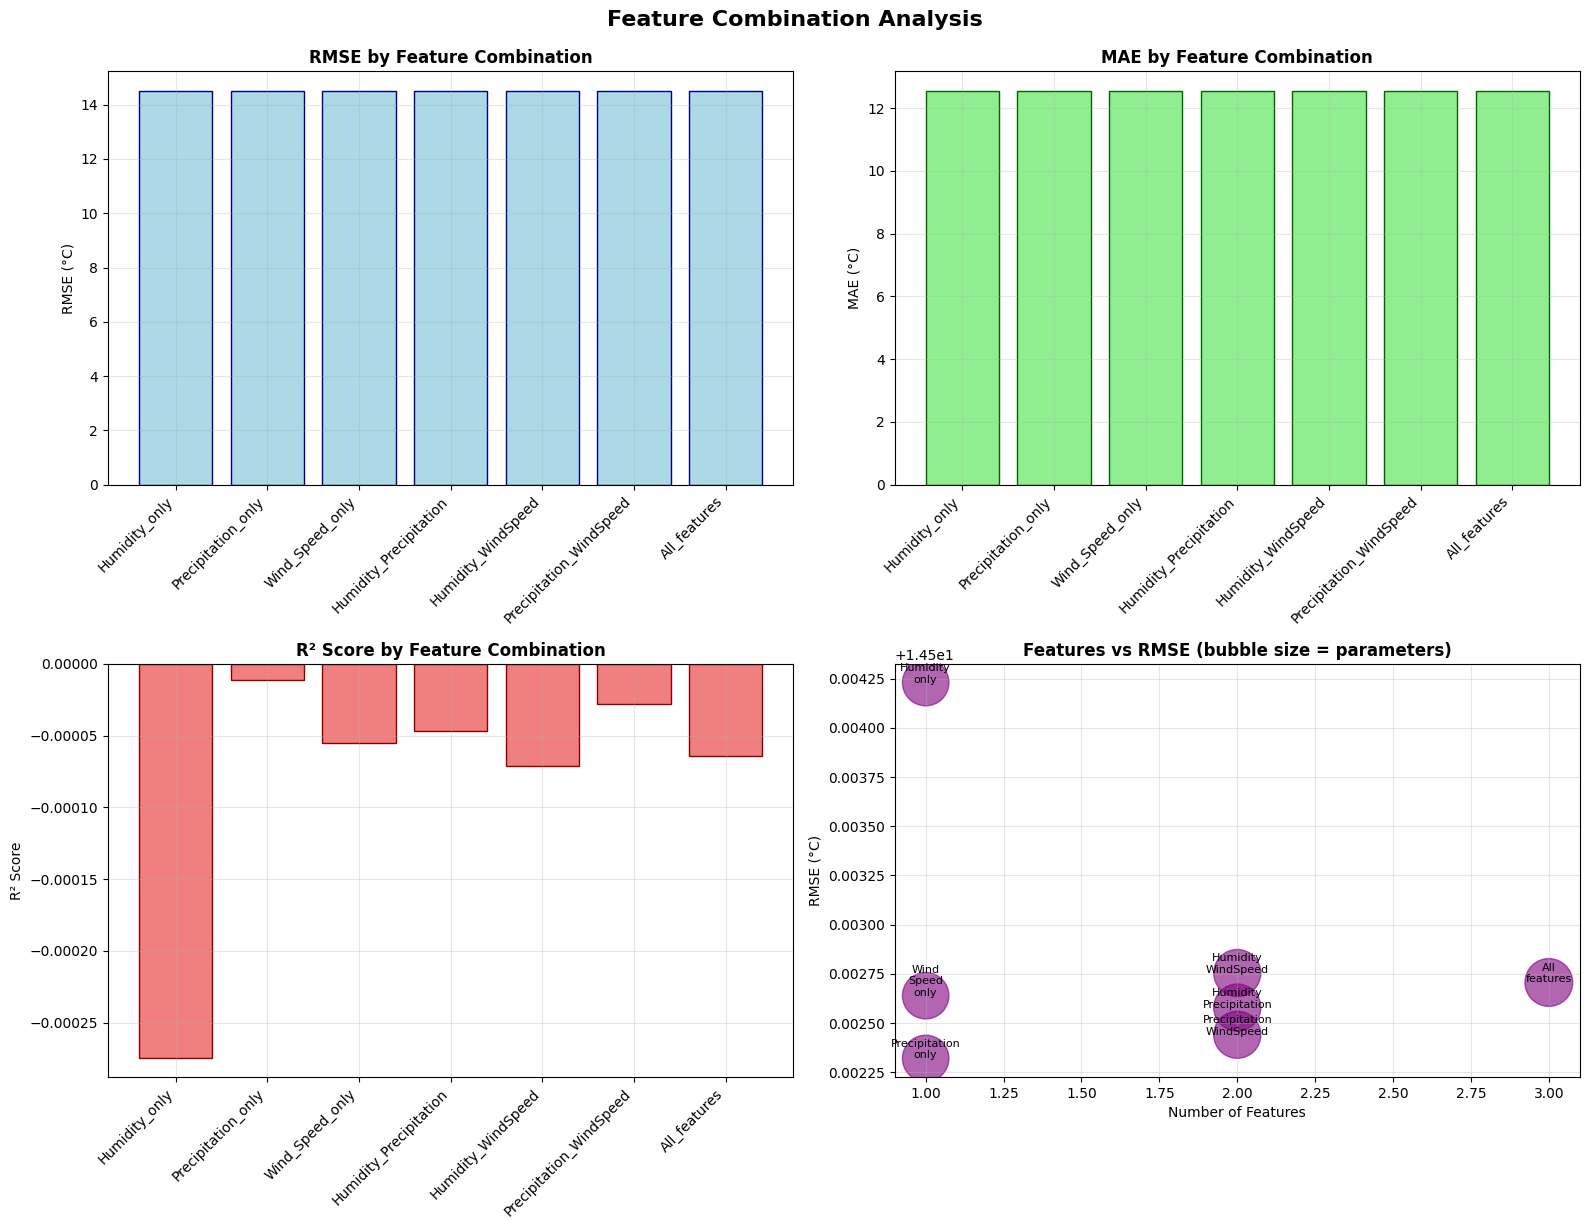


 Best Feature Combination: Precipitation_only
   Features: ['Precipitation_mm']
   RMSE: 14.5023°C
   R²: -0.0000


In [75]:
# Analyze results
df_feature_comparison = analyze_feature_combinations_results(feature_results)

### **Additional detailed analysis for feature combinations**


In [76]:
# Individual feature performance ranking
print("\n INDIVIDUAL FEATURE PERFORMANCE RANKING:")
print("="*60)

individual_features = {
    'Humidity_only': feature_results['Humidity_only'],
    'Precipitation_only': feature_results['Precipitation_only'], 
    'Wind_Speed_only': feature_results['Wind_Speed_only']
}

# Sort by RMSE (lower is better)
sorted_individual = sorted(individual_features.items(), key=lambda x: x[1]['rmse'])

for i, (feature_name, metrics) in enumerate(sorted_individual, 1):
    feature = metrics['features'][0]
    print(f"{i}. {feature}:")
    print(f"   RMSE: {metrics['rmse']:.4f}°C")
    print(f"   MAE:  {metrics['mae']:.4f}°C")
    print(f"   R²:   {metrics['r2']:.6f}")
    print(f"   MAPE: {metrics['mape']:.2f}%")

# Feature combination effectiveness analysis
print(f"\n FEATURE COMBINATION EFFECTIVENESS:")
print("="*60)

combinations = {
    'Two_feature_combos': {
        'Humidity_Precipitation': feature_results['Humidity_Precipitation'],
        'Humidity_WindSpeed': feature_results['Humidity_WindSpeed'],
        'Precipitation_WindSpeed': feature_results['Precipitation_WindSpeed']
    },
    'All_features': {
        'All_features': feature_results['All_features']
    }
}

for combo_type, combos in combinations.items():
    print(f"\n{combo_type.replace('_', ' ').title()}:")
    for combo_name, metrics in combos.items():
        features_str = " + ".join([f.replace('_', ' ') for f in metrics['features']])
        print(f"  {features_str}: RMSE = {metrics['rmse']:.4f}°C, R² = {metrics['r2']:.6f}")

# Model complexity vs performance analysis
print(f"\n⚙️ MODEL COMPLEXITY ANALYSIS:")
print("="*60)
for combo_name in feature_results.keys():
    metrics = feature_results[combo_name]
    efficiency = metrics['total_params'] / metrics['rmse'] if metrics['rmse'] > 0 else float('inf')
    print(f"{combo_name}: {metrics['num_features']} features, {metrics['total_params']:,} params, {efficiency:.0f} params/RMSE")


 INDIVIDUAL FEATURE PERFORMANCE RANKING:
1. Precipitation_mm:
   RMSE: 14.5023°C
   MAE:  12.5481°C
   R²:   -0.000011
   MAPE: 974.23%
2. Wind_Speed_kmh:
   RMSE: 14.5026°C
   MAE:  12.5485°C
   R²:   -0.000055
   MAPE: 978.41%
3. Humidity_pct:
   RMSE: 14.5042°C
   MAE:  12.5495°C
   R²:   -0.000274
   MAPE: 967.95%

 FEATURE COMBINATION EFFECTIVENESS:

Two Feature Combos:
  Humidity pct + Precipitation mm: RMSE = 14.5026°C, R² = -0.000047
  Humidity pct + Wind Speed kmh: RMSE = 14.5028°C, R² = -0.000071
  Precipitation mm + Wind Speed kmh: RMSE = 14.5024°C, R² = -0.000028

All Features:
  Humidity pct + Precipitation mm + Wind Speed kmh: RMSE = 14.5027°C, R² = -0.000064

⚙️ MODEL COMPLEXITY ANALYSIS:
Humidity_only: 1 features, 1,121 params, 77 params/RMSE
Precipitation_only: 1 features, 1,121 params, 77 params/RMSE
Wind_Speed_only: 1 features, 1,121 params, 77 params/RMSE
Humidity_Precipitation: 2 features, 1,153 params, 80 params/RMSE
Humidity_WindSpeed: 2 features, 1,153 params, 

## **Exercise 4: Experimenting with Different Target Variables**

**Goal**: Testing prediction of different weather variables and observing performance differences

**What we are doing**:
1. Predicting Temperature_C
2. Testing prediction of Humidity_pct, Precipitation_mm, and Wind_Speed_kmh
3. Comparing which weather variables are easier to predict using the same features

**Target variables to test**:
- Temperature_C (baseline)
- Humidity_pct 
- Precipitation_mm
- Wind_Speed_kmh

**Expected observations**:
- Some weather variables may be more predictable than others
- Different variables may have different correlation patterns with the features
- Understanding which weather phenomena are inherently more/less predictable

### **Creating the testing function for different target variables**

In [77]:
def test_different_targets():
    """
    Test prediction of different weather variables and compare performance
    """
    results = {}
    
    # Define target variables to test
    target_variables = {
        'Temperature_C': 'Temperature_C',
        'Humidity_pct': 'Humidity_pct', 
        'Precipitation_mm': 'Precipitation_mm',
        'Wind_Speed_kmh': 'Wind_Speed_kmh'
    }
    
    # Use best settings from previous exercises
    best_sequence_length = 5
    best_hidden_units = 32
    
    for target_name, target_column in target_variables.items():
        print(f"\n{'='*60}")
        print(f"Testing Target Variable: {target_name}")
        print(f"Target Column: {target_column}")
        print(f"{'='*60}")
        
        # Create feature columns (all other weather variables except the target)
        all_weather_features = ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
        feature_columns = [col for col in all_weather_features if col != target_column]
        
        print(f"Features used: {feature_columns}")
        print(f"Target: {target_column}")
        
        # Check correlations before training
        target_data = train_data[target_column]
        feature_data = train_data[feature_columns]
        correlations = feature_data.corrwith(target_data)
        print(f"Feature correlations with {target_name}:")
        for feature, corr in correlations.items():
            print(f"  {feature}: {corr:.6f}")
        
        # Prepare data with current target
        (X_train_temp, y_train_temp), (X_val_temp, y_val_temp), (X_test_temp, y_test_temp) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            feature_columns, target_column,
            feature_scaler, target_scaler,
            sequence_length=best_sequence_length
        )
        
        # Create model
        input_shape_temp = (X_train_temp.shape[1], X_train_temp.shape[2])
        model_temp = create_simple_rnn_model(input_shape_temp, hidden_units=best_hidden_units, dropout_rate=0.2)
        
        # Train model (fewer epochs for comparison)
        history_temp = train_simple_rnn_model(
            model_temp, X_train_temp, y_train_temp, X_val_temp, y_val_temp,
            epochs=20, batch_size=32, patience=5
        )
        
        # Evaluate
        eval_results = evaluate_simple_rnn_performance(model_temp, X_test_temp, y_test_temp, target_scaler)
        
        # Store results
        results[target_name] = {
            'target_column': target_column,
            'features': feature_columns,
            'num_features': len(feature_columns),
            'correlations': correlations.to_dict(),
            'rmse': eval_results['rmse'],
            'mae': eval_results['mae'],
            'r2': eval_results['r2'],
            'mape': eval_results['mape'],
            'total_params': model_temp.count_params()
        }
        
        # Clean up
        del model_temp
        
    return results

print("Different targets testing function created successfully!")

Different targets testing function created successfully!


### **Running the different target variables test**


In [78]:
# Run the test 
print("Starting different target variables comparison...")
target_results = test_different_targets()
print("Testing completed!")

Starting different target variables comparison...

Testing Target Variable: Temperature_C
Target Column: Temperature_C
Features used: ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Target: Temperature_C
Feature correlations with Temperature_C:
  Humidity_pct: -0.002068
  Precipitation_mm: -0.010103
  Wind_Speed_kmh: -0.001015
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature_C
Features (before filtering): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Features (numeric only): ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699995, 5, 3)
Training targets: (699995,)
Validation sequences: (149995, 5, 3)
Test sequences: (149995, 5, 3)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 3)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

...

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699995
Validation samples: 149995
Epochs: 20
Batch size: 32

Starting training...
Epoch 1/20
21811/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0933 - mean_absolute_error: 0.2594 - mean_absolute_percentage_error: 1916.7714
Epoch 1: val_loss improved from inf to 0.08378, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 13s 548us/step - loss: 0.0933 - mean_absolute_error: 0.2594 - mean_absolute_percentage_error: 1917.1267 - val_loss: 0.0838 - val_mean_absolute_error: 0.2508 - val_mean_absolute_percentage_error: 829.2952
Epoch 2/20
21773/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1980.9249
Epoch 2: val_loss did not improve from 0.08378
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 541us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1981.3625 - val_loss: 0.0838 - val_mean_absolute_error: 0.2508 - val_mean_absolute_percentage_error: 824.9705
Epoch 3/20
21807/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1978.0879
Epoch 3: val_loss improved from 0.08378 to 0.08378, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 541us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1978.3936 - val_loss: 0.0838 - val_mean_absolute_error: 0.2508 - val_mean_absolute_percentage_error: 832.0510
Epoch 4/20
21790/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1976.5973
Epoch 4: val_loss did not improve from 0.08378
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 541us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1977.0079 - val_loss: 0.0838 - val_mean_absolute_error: 0.2508 - val_mean_absolute_percentage_error: 827.9604
Epoch 5/20
21775/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1982.2163
Epoch 5: val_loss did not improve from 0.08378
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 540us/step - loss: 0.0836 - mean_absolute_error: 0.2504 - mean_absolute_percentage_error: 1982.6686 -

### **Creating the analysis function for different target variables**

In [81]:
def analyze_target_variables_results(results):
    """
    Analyze and visualize different target variables experiment results
    """
    # Convert to DataFrame for easy analysis
    df_results = pd.DataFrame(results).T
    
    print("\n TARGET VARIABLES COMPARISON RESULTS")
    print("="*70)
    print(df_results[['num_features', 'rmse', 'mae', 'r2', 'mape']].round(4))
    
    # Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    target_names = list(results.keys())
    
    # 1. RMSE comparison
    rmse_values = [results[target]['rmse'] for target in target_names]
    axes[0, 0].bar(range(len(target_names)), rmse_values, color='skyblue', edgecolor='navy')
    axes[0, 0].set_title('RMSE by Target Variable', fontweight='bold')
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].set_xticks(range(len(target_names)))
    axes[0, 0].set_xticklabels(target_names, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. MAE comparison
    mae_values = [results[target]['mae'] for target in target_names]
    axes[0, 1].bar(range(len(target_names)), mae_values, color='lightgreen', edgecolor='darkgreen')
    axes[0, 1].set_title('MAE by Target Variable', fontweight='bold')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].set_xticks(range(len(target_names)))
    axes[0, 1].set_xticklabels(target_names, rotation=45, ha='right')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. R² comparison
    r2_values = [results[target]['r2'] for target in target_names]
    axes[0, 2].bar(range(len(target_names)), r2_values, color='lightcoral', edgecolor='darkred')
    axes[0, 2].set_title('R² Score by Target Variable', fontweight='bold')
    axes[0, 2].set_ylabel('R² Score')
    axes[0, 2].set_xticks(range(len(target_names)))
    axes[0, 2].set_xticklabels(target_names, rotation=45, ha='right')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. MAPE comparison
    mape_values = [results[target]['mape'] for target in target_names]
    axes[1, 0].bar(range(len(target_names)), mape_values, color='plum', edgecolor='purple')
    axes[1, 0].set_title('MAPE by Target Variable', fontweight='bold')
    axes[1, 0].set_ylabel('MAPE (%)')
    axes[1, 0].set_xticks(range(len(target_names)))
    axes[1, 0].set_xticklabels(target_names, rotation=45, ha='right')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Correlation strength analysis
    # Calculate average absolute correlation for each target
    avg_correlations = {}
    for target_name, data in results.items():
        correlations = list(data['correlations'].values())
        avg_abs_corr = sum(abs(c) for c in correlations) / len(correlations)
        avg_correlations[target_name] = avg_abs_corr
    
    corr_names = list(avg_correlations.keys())
    corr_values = list(avg_correlations.values())
    
    axes[1, 1].bar(range(len(corr_names)), corr_values, color='gold', edgecolor='orange')
    axes[1, 1].set_title('Average Absolute Correlation with Features', fontweight='bold')
    axes[1, 1].set_ylabel('Average |Correlation|')
    axes[1, 1].set_xticks(range(len(corr_names)))
    axes[1, 1].set_xticklabels(corr_names, rotation=45, ha='right')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Performance vs Correlation scatter plot
    axes[1, 2].scatter(corr_values, rmse_values, s=100, alpha=0.7, c='red')
    axes[1, 2].set_xlabel('Average |Correlation| with Features')
    axes[1, 2].set_ylabel('RMSE')
    axes[1, 2].set_title('Performance vs Feature Correlation', fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add labels to scatter plot
    for i, target in enumerate(corr_names):
        axes[1, 2].annotate(target, (corr_values[i], rmse_values[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    plt.tight_layout()
    plt.suptitle('Target Variables Analysis', fontsize=16, y=1.02, fontweight='bold')
    plt.show()
    
    # Find best and worst targets to predict
    best_target = min(results.keys(), key=lambda x: results[x]['rmse'])
    worst_target = max(results.keys(), key=lambda x: results[x]['rmse'])
    
    print(f"\n Easiest to Predict: {best_target}")
    print(f"   RMSE: {results[best_target]['rmse']:.4f}")
    print(f"   R²: {results[best_target]['r2']:.6f}")
    print(f"   Avg |Correlation|: {avg_correlations[best_target]:.6f}")
    
    print(f"\n🎯 Hardest to Predict: {worst_target}")
    print(f"   RMSE: {results[worst_target]['rmse']:.4f}")
    print(f"   R²: {results[worst_target]['r2']:.6f}")
    print(f"   Avg |Correlation|: {avg_correlations[worst_target]:.6f}")
    
    return df_results

print("Target variables analysis function created successfully!")

Target variables analysis function created successfully!


### **Analyzing and visualizing target variables results**



 TARGET VARIABLES COMPARISON RESULTS
                 num_features       rmse        mae        r2        mape
Temperature_C               3   14.50281  12.548567 -0.000079  976.729987
Humidity_pct                3  17.375617  15.064263 -0.000259   28.972494
Precipitation_mm            3   2.946873   2.536392 -0.000362  531.364154
Wind_Speed_kmh              3   8.653174   7.486376 -0.000962  522.357315


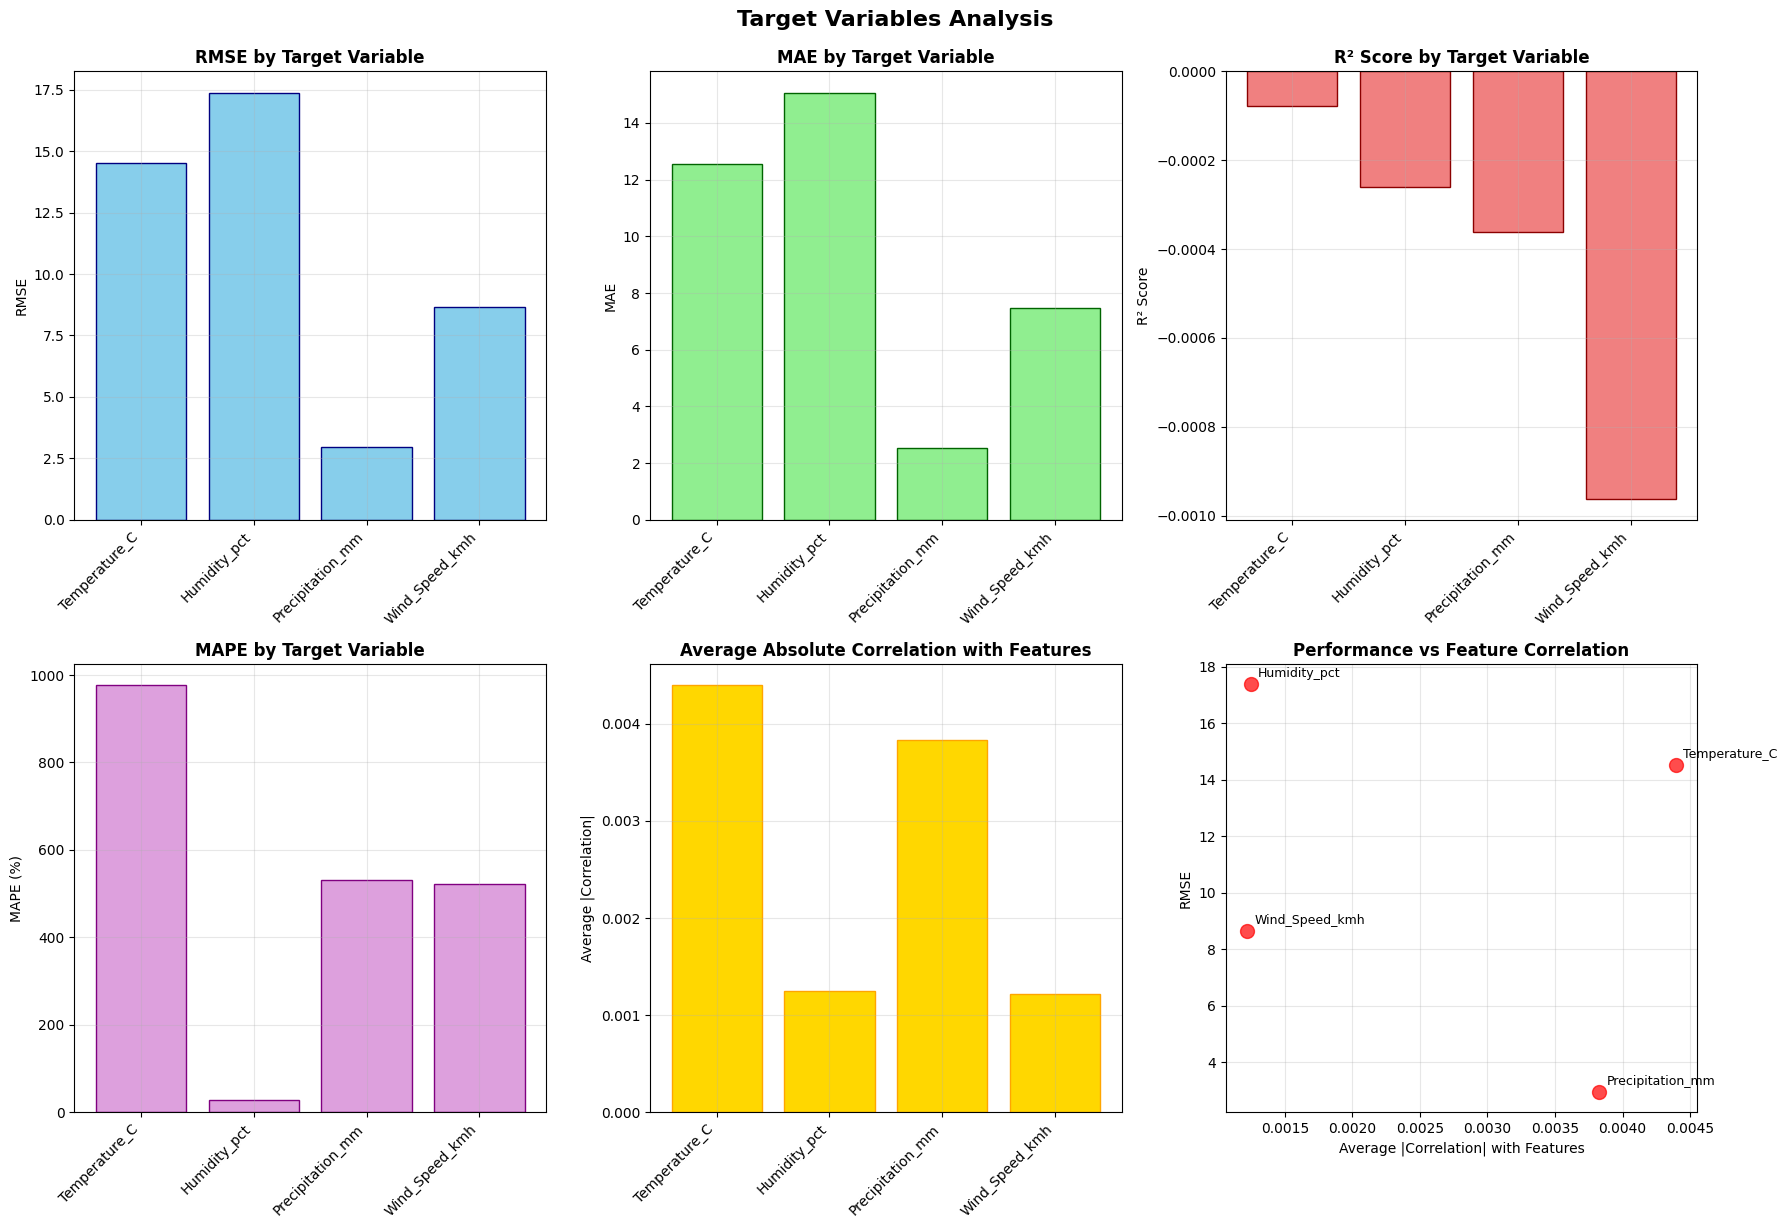


 Easiest to Predict: Precipitation_mm
   RMSE: 2.9469
   R²: -0.000362
   Avg |Correlation|: 0.003828

🎯 Hardest to Predict: Humidity_pct
   RMSE: 17.3756
   R²: -0.000259
   Avg |Correlation|: 0.001245


In [82]:
# Analyze results
df_target_comparison = analyze_target_variables_results(target_results)

### **Additional detailed analysis for target variables**


In [83]:
# Detailed correlation analysis for each target
print("\n DETAILED CORRELATION ANALYSIS:")
print("="*70)

for target_name, data in target_results.items():
    print(f"\n{target_name} prediction:")
    print(f"Features used: {data['features']}")
    print("Correlations with features:")
    for feature, corr in data['correlations'].items():
        print(f"  {feature}: {corr:+.6f}")
    print(f"Performance: RMSE={data['rmse']:.4f}, R²={data['r2']:.6f}")

# Predictability ranking
print(f"\n PREDICTABILITY RANKING (by RMSE):")
print("="*70)

sorted_targets = sorted(target_results.items(), key=lambda x: x[1]['rmse'])

for i, (target_name, data) in enumerate(sorted_targets, 1):
    avg_abs_corr = sum(abs(c) for c in data['correlations'].values()) / len(data['correlations'])
    print(f"{i}. {target_name}:")
    print(f"   RMSE: {data['rmse']:.4f}")
    print(f"   R²: {data['r2']:.6f}")
    print(f"   MAPE: {data['mape']:.2f}%")
    print(f"   Avg |Correlation|: {avg_abs_corr:.6f}")

# Feature importance across different targets
print(f"\n🎯 FEATURE IMPORTANCE ACROSS TARGETS:")
print("="*70)

# Collect all correlations for each feature
feature_importance = {}
all_features = set()
for target_data in target_results.values():
    all_features.update(target_data['correlations'].keys())

for feature in all_features:
    correlations = []
    targets_using_feature = []
    for target_name, target_data in target_results.items():
        if feature in target_data['correlations']:
            correlations.append(abs(target_data['correlations'][feature]))
            targets_using_feature.append(target_name)
    
    if correlations:
        avg_importance = sum(correlations) / len(correlations)
        feature_importance[feature] = {
            'avg_abs_correlation': avg_importance,
            'targets': targets_using_feature,
            'correlations': correlations
        }

# Sort features by average importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1]['avg_abs_correlation'], reverse=True)

print("Features ranked by average absolute correlation across all targets:")
for i, (feature, data) in enumerate(sorted_features, 1):
    print(f"{i}. {feature}:")
    print(f"   Avg |Correlation|: {data['avg_abs_correlation']:.6f}")
    print(f"   Used as feature for predicting: {', '.join(data['targets'])}")

# Target variable characteristics
print(f"\n TARGET VARIABLE CHARACTERISTICS:")
print("="*70)

for target_name, data in target_results.items():
    target_column = data['target_column']
    target_stats = train_data[target_column].describe()
    
    print(f"\n{target_name} ({target_column}):")
    print(f"   Mean: {target_stats['mean']:.2f}")
    print(f"   Std: {target_stats['std']:.2f}")
    print(f"   Range: {target_stats['min']:.2f} to {target_stats['max']:.2f}")
    print(f"   Coefficient of Variation: {(target_stats['std']/target_stats['mean'])*100:.1f}%")


 DETAILED CORRELATION ANALYSIS:

Temperature_C prediction:
Features used: ['Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
Correlations with features:
  Humidity_pct: -0.002068
  Precipitation_mm: -0.010103
  Wind_Speed_kmh: -0.001015
Performance: RMSE=14.5028, R²=-0.000079

Humidity_pct prediction:
Features used: ['Temperature_C', 'Precipitation_mm', 'Wind_Speed_kmh']
Correlations with features:
  Temperature_C: -0.002068
  Precipitation_mm: -0.000200
  Wind_Speed_kmh: -0.001467
Performance: RMSE=17.3756, R²=-0.000259

Precipitation_mm prediction:
Features used: ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Correlations with features:
  Temperature_C: -0.010103
  Humidity_pct: -0.000200
  Wind_Speed_kmh: +0.001181
Performance: RMSE=2.9469, R²=-0.000362

Wind_Speed_kmh prediction:
Features used: ['Temperature_C', 'Humidity_pct', 'Precipitation_mm']
Correlations with features:
  Temperature_C: -0.001015
  Humidity_pct: -0.001467
  Precipitation_mm: +0.001181
Performance: RM

## Exercise 5: Conducting Error Analysis

**Goal**: Identifying when the model makes the largest errors and understanding failure patterns

1. Analyzing prediction errors from the best performing model
2. Identifying patterns in when predictions fail
3. Understanding relationship between input characteristics and error magnitude

**Analysis components**:
- Error distribution analysis
- High-error case identification
- Feature value correlation with errors
- Temporal error patterns
- Error magnitude vs input characteristics

**Expected observations**:
- Certain input ranges may produce larger errors
- Error patterns may reveal data quality issues
- Understanding model limitations and failure modes

### **Creating the error analysis function**

In [84]:
def conduct_error_analysis():
    """
    Conduct comprehensive error analysis on the best performing model
    """
    # Use the best target from Exercise 4 (Precipitation was best)
    best_target = 'Precipitation_mm'
    
    print(f"Conducting error analysis for {best_target} prediction")
    print("="*60)
    
    # Use best settings
    best_sequence_length = 5
    best_hidden_units = 32
    all_weather_features = ['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']
    feature_columns = [col for col in all_weather_features if col != best_target]
    
    # Prepare data
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_for_simple_rnn(
        train_data, val_data, test_data,
        feature_columns, best_target,
        feature_scaler, target_scaler,
        sequence_length=best_sequence_length
    )
    
    # Create and train model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = create_simple_rnn_model(input_shape, hidden_units=best_hidden_units, dropout_rate=0.2)
    
    # Train model
    history = train_simple_rnn_model(
        model, X_train, y_train, X_val, y_val,
        epochs=30, batch_size=32, patience=5
    )
    
    # Make predictions on test set
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Inverse transform to original scale
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = target_scaler.inverse_transform(y_pred_scaled).flatten()
    
    # Calculate errors
    errors = y_test_original - y_pred_original
    abs_errors = np.abs(errors)
    squared_errors = errors ** 2
    
    # Get feature values for analysis
    # Reconstruct original feature values for test set
    test_start_idx = len(train_data) + len(val_data) + best_sequence_length
    original_test_features = df_processed.iloc[test_start_idx:test_start_idx + len(y_test_original)][feature_columns]
    
    # Store results
    error_analysis_results = {
        'target_variable': best_target,
        'y_true': y_test_original,
        'y_pred': y_pred_original,
        'errors': errors,
        'abs_errors': abs_errors,
        'squared_errors': squared_errors,
        'features': original_test_features,
        'feature_names': feature_columns,
        'model': model,
        'history': history
    }
    
    print(f"Error analysis data prepared successfully!")
    print(f"Test samples: {len(y_test_original)}")
    print(f"Feature columns: {feature_columns}")
    
    return error_analysis_results

print("Error analysis function created successfully!")

Error analysis function created successfully!


### **Running the error analysis**

In [85]:
# Run the error analysis - this will take a few minutes
print("Starting comprehensive error analysis...")
error_data = conduct_error_analysis()
print("Error analysis completed!")

Starting comprehensive error analysis...
Conducting error analysis for Precipitation_mm prediction
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Precipitation_mm
Features (before filtering): ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Features (numeric only): ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699995, 5, 3)
Training targets: (699995,)
Validation sequences: (149995, 5, 3)
Test sequences: (149995, 5, 3)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 3)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

...

21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 541us/step - loss: 0.0494 - mean_absolute_error: 0.1831 - mean_absolute_percentage_error: 8687.4727 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 597.1411
Epoch 2/30
21776/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4616.3403
Epoch 2: val_loss improved from 0.03895 to 0.03895, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 543us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4602.0864 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 596.2147
Epoch 3/30
21868/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4617.0229
Epoch 3: val_loss did not improve from 0.03895
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 544us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4615.8838 - val_loss: 0.0390 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 597.1002
Epoch 4/30
21785/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4578.7866
Epoch 4: val_loss improved from 0.03895 to 0.03895, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 543us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4565.9473 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 597.4911
Epoch 5/30
21807/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4628.6914
Epoch 5: val_loss improved from 0.03895 to 0.03895, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 543us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4618.8096 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 597.2635
Epoch 6/30
21819/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4613.0283
Epoch 6: val_loss improved from 0.03895 to 0.03894, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 542us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4604.9307 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 598.0025
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Training completed!
Error analysis data prepared successfully!
Test samples: 149995
Feature columns: ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Error analysis completed!


### **Creating the error visualization and analysis function**

In [92]:
def visualize_error_analysis(error_data):
    """
    Create comprehensive visualizations and analysis of prediction errors
    """
    print("\n COMPREHENSIVE ERROR ANALYSIS")
    print("="*60)
    
    # Extract data
    y_true = error_data['y_true']
    y_pred = error_data['y_pred']
    errors = error_data['errors']
    abs_errors = error_data['abs_errors']
    features = error_data['features']
    feature_names = error_data['feature_names']
    
    # Basic error statistics
    print(f"Error Statistics:")
    print(f"  Mean Error: {np.mean(errors):.4f}")
    print(f"  Mean Absolute Error: {np.mean(abs_errors):.4f}")
    print(f"  RMSE: {np.sqrt(np.mean(errors**2)):.4f}")
    print(f"  Error Std: {np.std(errors):.4f}")
    print(f"  Max Error: {np.max(np.abs(errors)):.4f}")
    
    # Create comprehensive visualizations
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    
    # 1. Error distribution
    axes[0, 0].hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_title('Error Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Prediction Error')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Absolute error distribution
    axes[0, 1].hist(abs_errors, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title('Absolute Error Distribution', fontweight='bold')
    axes[0, 1].set_xlabel('Absolute Prediction Error')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Actual vs Predicted scatter
    axes[0, 2].scatter(y_true, y_pred, alpha=0.5, s=20)
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[0, 2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[0, 2].set_title('Actual vs Predicted', fontweight='bold')
    axes[0, 2].set_xlabel('Actual Values')
    axes[0, 2].set_ylabel('Predicted Values')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Error vs actual values
    axes[1, 0].scatter(y_true, abs_errors, alpha=0.5, s=20, color='orange')
    axes[1, 0].set_title('Absolute Error vs Actual Values', fontweight='bold')
    axes[1, 0].set_xlabel('Actual Values')
    axes[1, 0].set_ylabel('Absolute Error')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Error over time (sequence)
    axes[1, 1].plot(abs_errors[:500], alpha=0.7, color='purple')  # Plot first 500 points
    axes[1, 1].set_title('Error Over Time (First 500 predictions)', fontweight='bold')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Absolute Error')
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. High error cases analysis
    high_error_threshold = np.percentile(abs_errors, 90)  # Top 10% errors
    high_error_mask = abs_errors >= high_error_threshold
    
    axes[1, 2].scatter(y_true[~high_error_mask], abs_errors[~high_error_mask], 
                      alpha=0.5, s=20, color='lightblue', label='Normal errors')
    axes[1, 2].scatter(y_true[high_error_mask], abs_errors[high_error_mask], 
                      alpha=0.8, s=40, color='red', label='High errors (top 10%)')
    axes[1, 2].axhline(high_error_threshold, color='red', linestyle='--', alpha=0.7)
    axes[1, 2].set_title('High Error Cases Identification', fontweight='bold')
    axes[1, 2].set_xlabel('Actual Values')
    axes[1, 2].set_ylabel('Absolute Error')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    # 7-9. Feature correlation with errors
    for i, feature in enumerate(feature_names[:3]):  # Plot first 3 features
        if i < 3:
            feature_values = features[feature].values
            axes[2, i].scatter(feature_values, abs_errors, alpha=0.5, s=20)
            axes[2, i].set_title(f'Error vs {feature}', fontweight='bold')
            axes[2, i].set_xlabel(feature)
            axes[2, i].set_ylabel('Absolute Error')
            axes[2, i].grid(True, alpha=0.3)
            
            # Calculate correlation
            corr = np.corrcoef(feature_values, abs_errors)[0, 1]
            axes[2, i].text(0.05, 0.95, f'Corr: {corr:.4f}', 
                           transform=axes[2, i].transAxes,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.suptitle(f'Error Analysis: {error_data["target_variable"]} Prediction', 
                 fontsize=16, y=1.02, fontweight='bold')
    plt.show()
    
    # Identify high error cases
    print(f"\n HIGH ERROR CASES ANALYSIS:")
    print("="*50)
    print(f"High error threshold (90th percentile): {high_error_threshold:.4f}")
    print(f"Number of high error cases: {np.sum(high_error_mask)} out of {len(abs_errors)}")
    print(f"Percentage of high error cases: {np.sum(high_error_mask)/len(abs_errors)*100:.1f}%")
    
    # Feature correlations with errors
    print(f"\n FEATURE CORRELATIONS WITH ERRORS:")
    print("="*50)
    for feature in feature_names:
        feature_values = features[feature].values
        corr = np.corrcoef(feature_values, abs_errors)[0, 1]
        print(f"{feature}: {corr:+.6f}")
    
    return {
        'high_error_threshold': high_error_threshold,
        'high_error_mask': high_error_mask,
        'error_stats': {
            'mean_error': np.mean(errors),
            'mae': np.mean(abs_errors),
            'rmse': np.sqrt(np.mean(errors**2)),
            'error_std': np.std(errors),
            'max_error': np.max(np.abs(errors))
        }
    }

print("Error visualization function created successfully!")

Error visualization function created successfully!


### **Running the error analysis**

In [87]:
# Run the error analysis 
print("Starting comprehensive error analysis...")
error_data = conduct_error_analysis()
print("Error analysis completed!")

Starting comprehensive error analysis...
Conducting error analysis for Precipitation_mm prediction
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Precipitation_mm
Features (before filtering): ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Features (numeric only): ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Train Target : (700000,)
Training sequences: (699995, 5, 3)
Training targets: (699995,)
Validation sequences: (149995, 5, 3)
Test sequences: (149995, 5, 3)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 3)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

...

=== TRAINING SIMPLE RNN MODEL ===
Training samples: 699995
Validation samples: 149995
Epochs: 30
Batch size: 32

Starting training...
Epoch 1/30
21851/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 0.0471 - mean_absolute_error: 0.1801 - mean_absolute_percentage_error: 5142.4907
Epoch 1: val_loss improved from inf to 0.03897, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 13s 556us/step - loss: 0.0471 - mean_absolute_error: 0.1801 - mean_absolute_percentage_error: 5138.4004 - val_loss: 0.0390 - val_mean_absolute_error: 0.1698 - val_mean_absolute_percentage_error: 597.7648
Epoch 2/30
21855/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4640.2178
Epoch 2: val_loss improved from 0.03897 to 0.03895, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 544us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4637.2070 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 598.3660
Epoch 3/30
21811/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4574.9707
Epoch 3: val_loss improved from 0.03895 to 0.03894, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 557us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4565.8154 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 596.3804
Epoch 4/30
21837/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4582.0776
Epoch 4: val_loss did not improve from 0.03894
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 534us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4576.5742 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 596.2614
Epoch 5/30
21786/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4601.9775
Epoch 5: val_loss improved from 0.03894 to 0.03894, saving model to best_simple_rnn_model.h5


21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 534us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4589.2212 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 597.2531
Epoch 6/30
21782/21875 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4622.9839
Epoch 6: val_loss did not improve from 0.03894
21875/21875 ━━━━━━━━━━━━━━━━━━━━ 12s 533us/step - loss: 0.0391 - mean_absolute_error: 0.1700 - mean_absolute_percentage_error: 4609.5630 - val_loss: 0.0389 - val_mean_absolute_error: 0.1697 - val_mean_absolute_percentage_error: 599.3785
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Training completed!
Error analysis data prepared successfully!
Test samples: 149995
Feature columns: ['Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh']
Error analysis completed!


### **Running the comprehensive error analysis**


 COMPREHENSIVE ERROR ANALYSIS
Error Statistics:
  Mean Error: 0.0281
  Mean Absolute Error: 2.5369
  RMSE: 2.9477
  Error Std: 2.9476
  Max Error: 9.9004


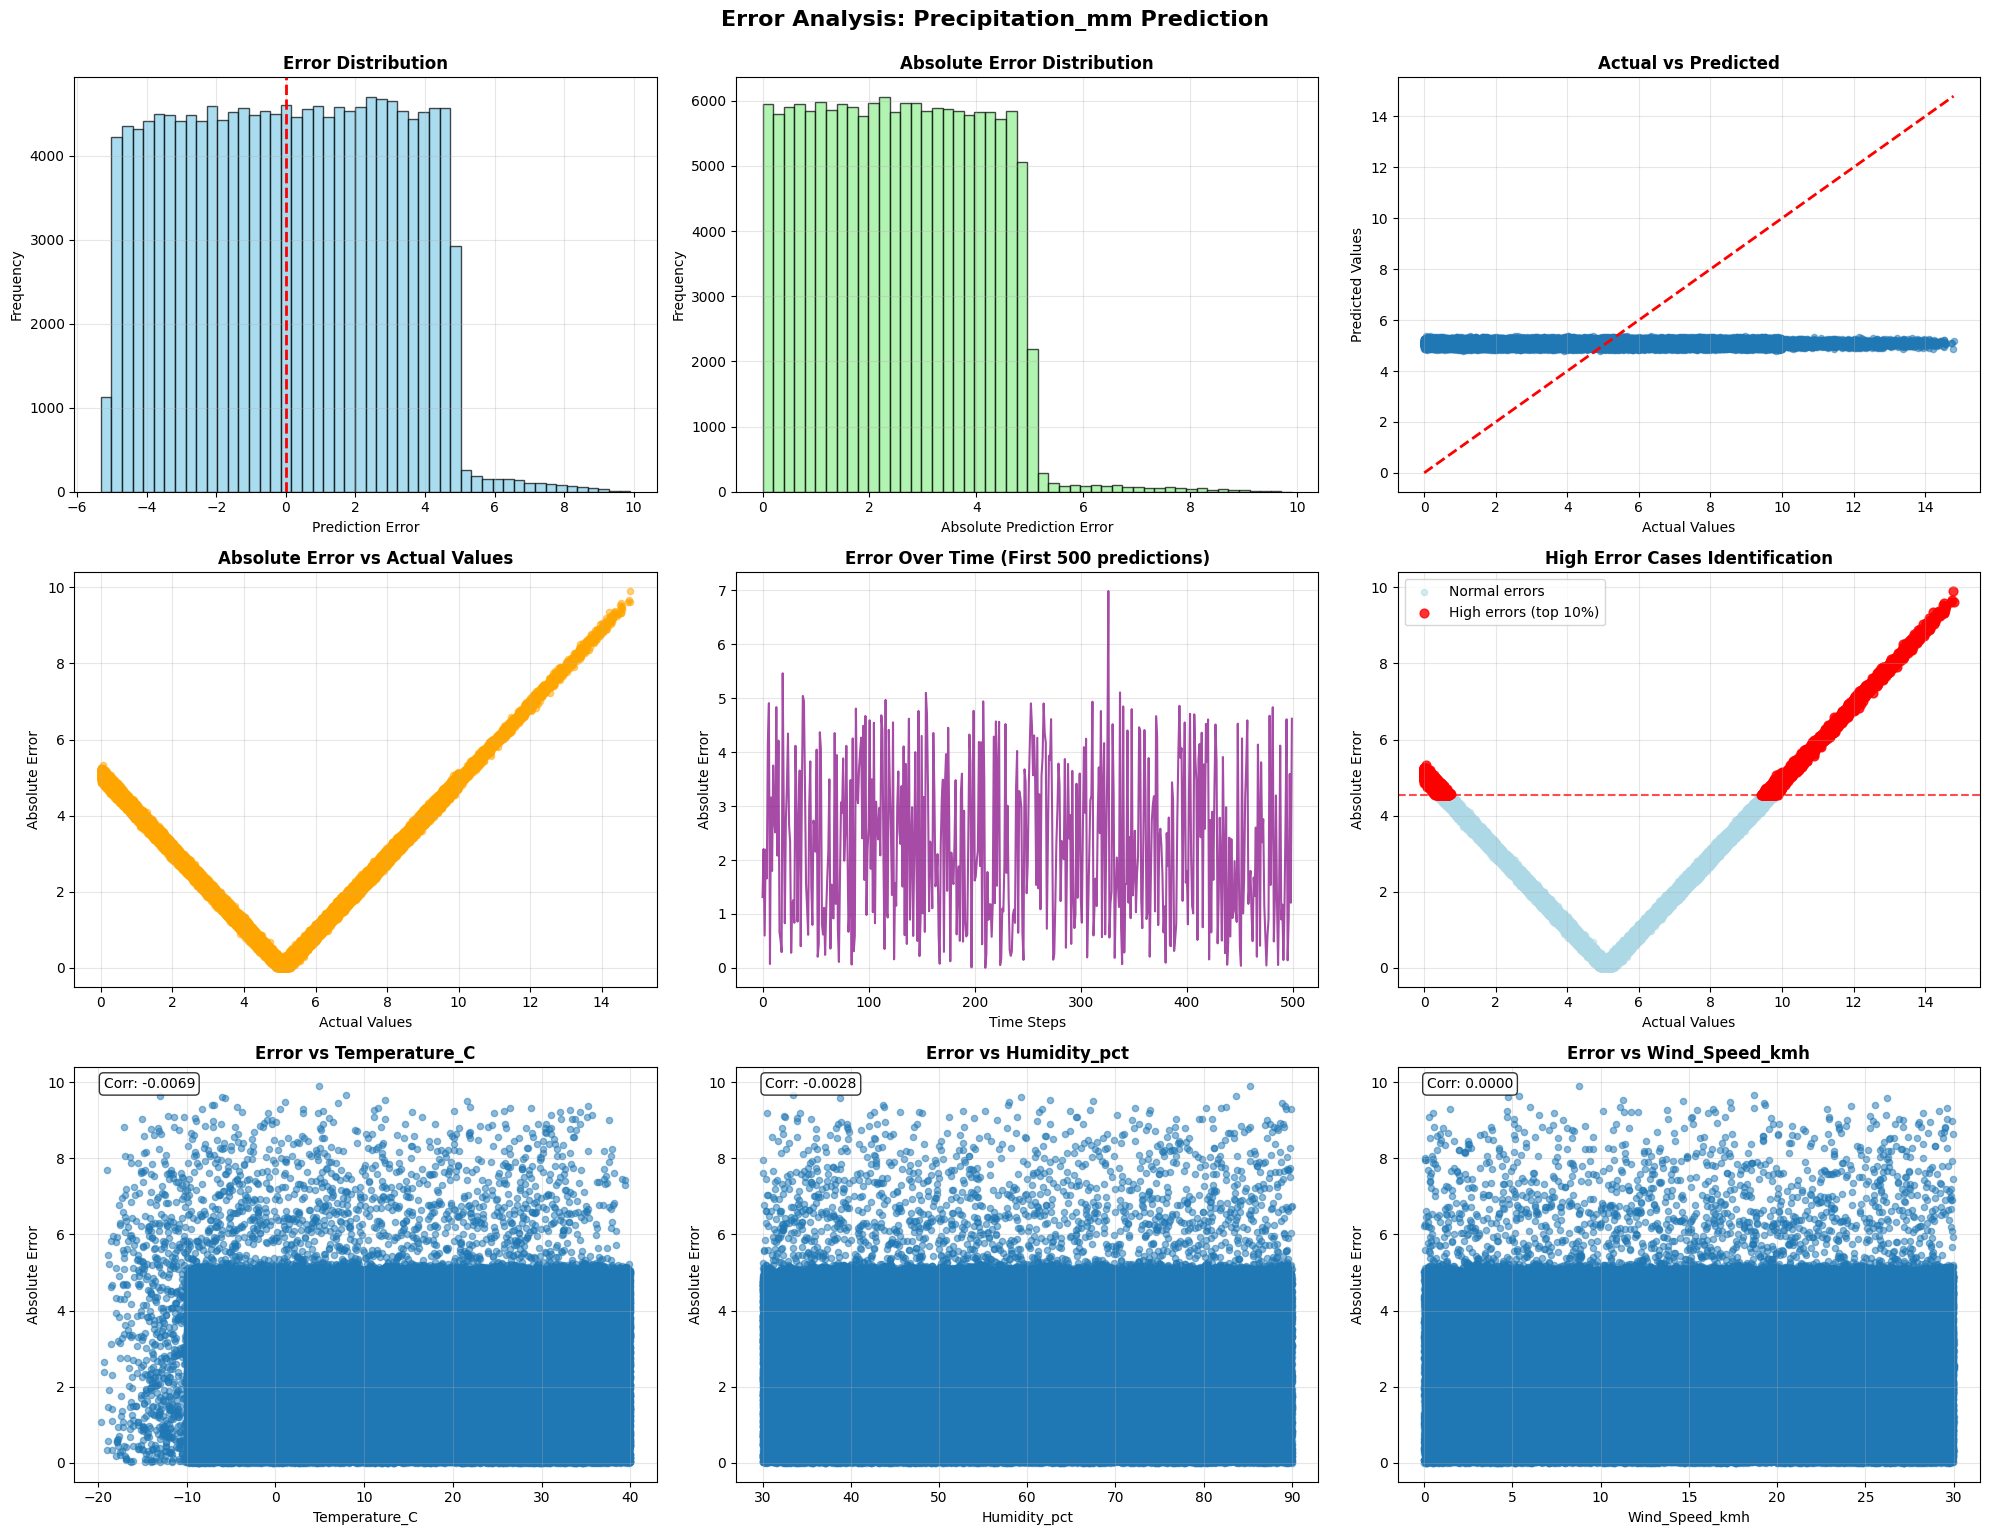


 HIGH ERROR CASES ANALYSIS:
High error threshold (90th percentile): 4.5445
Number of high error cases: 15000 out of 149995
Percentage of high error cases: 10.0%

 FEATURE CORRELATIONS WITH ERRORS:
Temperature_C: -0.006926
Humidity_pct: -0.002828
Wind_Speed_kmh: +0.000010


In [93]:
# Analyze errors and create visualizations
error_analysis = visualize_error_analysis(error_data)

### **Additional detailed error analysis**

In [91]:
# Deep dive into error patterns
print("\n DETAILED ERROR PATTERN ANALYSIS:")
print("="*60)

y_true = error_data['y_true']
y_pred = error_data['y_pred']
errors = error_data['errors']
abs_errors = error_data['abs_errors']
features = error_data['features']
feature_names = error_data['feature_names']

# 1. Error quartile analysis
error_quartiles = np.percentile(abs_errors, [25, 50, 75, 90, 95, 99])
print("Error Quartiles:")
for i, (pct, val) in enumerate(zip([25, 50, 75, 90, 95, 99], error_quartiles)):
    print(f"  {pct}th percentile: {val:.4f}")

# 2. Analyze extreme cases
print(f"\n EXTREME ERROR CASES:")
print("="*40)

# Worst 10 predictions
worst_indices = np.argsort(abs_errors)[-10:]
print("Worst 10 predictions:")
for i, idx in enumerate(worst_indices[::-1], 1):  # Reverse to get highest first
    print(f"{i}. Index {idx}: Actual={y_true[idx]:.4f}, Predicted={y_pred[idx]:.4f}, Error={abs_errors[idx]:.4f}")

# 3. Error by actual value ranges
print(f"\n ERROR BY ACTUAL VALUE RANGES:")
print("="*40)

# Create value bins
actual_min, actual_max = y_true.min(), y_true.max()
value_bins = np.linspace(actual_min, actual_max, 6)  # 5 bins
bin_labels = [f"{value_bins[i]:.2f}-{value_bins[i+1]:.2f}" for i in range(len(value_bins)-1)]

for i in range(len(value_bins)-1):
    mask = (y_true >= value_bins[i]) & (y_true < value_bins[i+1])
    if np.sum(mask) > 0:
        mean_error = np.mean(abs_errors[mask])
        count = np.sum(mask)
        print(f"Range {bin_labels[i]}: Mean Error={mean_error:.4f}, Count={count}")

# 4. Feature value ranges for high errors
high_error_threshold = np.percentile(abs_errors, 90)
high_error_mask = abs_errors >= high_error_threshold

print(f"\n HIGH ERROR FEATURE CHARACTERISTICS:")
print("="*50)

for feature in feature_names:
    feature_values = features[feature].values
    
    # Compare feature distributions for high vs normal errors
    high_error_features = feature_values[high_error_mask]
    normal_error_features = feature_values[~high_error_mask]
    
    print(f"\n{feature}:")
    print(f"  High error cases - Mean: {np.mean(high_error_features):.4f}, Std: {np.std(high_error_features):.4f}")
    print(f"  Normal cases - Mean: {np.mean(normal_error_features):.4f}, Std: {np.std(normal_error_features):.4f}")
    
    # Statistical test (simple comparison)
    diff_in_means = np.mean(high_error_features) - np.mean(normal_error_features)
    print(f"  Difference in means: {diff_in_means:+.4f}")

# 5. Model prediction bias analysis
print(f"\n PREDICTION BIAS ANALYSIS:")
print("="*40)

# Overall bias
overall_bias = np.mean(errors)
print(f"Overall prediction bias: {overall_bias:+.4f}")

# Bias by prediction ranges
pred_bins = np.linspace(y_pred.min(), y_pred.max(), 6)
pred_bin_labels = [f"{pred_bins[i]:.2f}-{pred_bins[i+1]:.2f}" for i in range(len(pred_bins)-1)]

print("\nBias by predicted value ranges:")
for i in range(len(pred_bins)-1):
    mask = (y_pred >= pred_bins[i]) & (y_pred < pred_bins[i+1])
    if np.sum(mask) > 0:
        bias = np.mean(errors[mask])
        count = np.sum(mask)
        print(f"Predicted {pred_bin_labels[i]}: Bias={bias:+.4f}, Count={count}")

# 6. Error correlation summary
print(f"\n ERROR CORRELATION SUMMARY:")
print("="*40)

correlations_with_errors = {}
for feature in feature_names:
    feature_values = features[feature].values
    corr_with_abs_error = np.corrcoef(feature_values, abs_errors)[0, 1]
    corr_with_actual = np.corrcoef(feature_values, y_true)[0, 1]
    correlations_with_errors[feature] = {
        'error_corr': corr_with_abs_error,
        'actual_corr': corr_with_actual
    }

print("Feature correlations:")
for feature, corrs in correlations_with_errors.items():
    print(f"{feature}:")
    print(f"  With absolute errors: {corrs['error_corr']:+.6f}")
    print(f"  With actual values: {corrs['actual_corr']:+.6f}")

# 7. Model performance insights
print(f"\n KEY INSIGHTS:")
print("="*40)

# Identify patterns
max_error_corr_feature = max(correlations_with_errors.keys(), 
                           key=lambda x: abs(correlations_with_errors[x]['error_corr']))
print(f"Feature most correlated with errors: {max_error_corr_feature}")
print(f"  Correlation: {correlations_with_errors[max_error_corr_feature]['error_corr']:+.6f}")

if abs(overall_bias) > 0.01:
    bias_direction = "over-predicting" if overall_bias < 0 else "under-predicting"
    print(f"Model shows systematic bias: {bias_direction} by {abs(overall_bias):.4f} on average")
else:
    print("Model shows minimal systematic bias")

print(f"Error variability: {np.std(abs_errors):.4f} (high values indicate inconsistent performance)")


 DETAILED ERROR PATTERN ANALYSIS:
Error Quartiles:
  25th percentile: 1.2586
  50th percentile: 2.5142
  75th percentile: 3.7752
  90th percentile: 4.5445
  95th percentile: 4.8022
  99th percentile: 5.2038

 EXTREME ERROR CASES:
Worst 10 predictions:
1. Index 143100: Actual=14.7763, Predicted=4.8759, Error=9.9004
2. Index 73008: Actual=14.7596, Predicted=5.0942, Error=9.6654
3. Index 2485: Actual=14.7955, Predicted=5.1684, Error=9.6271
4. Index 41502: Actual=14.7362, Predicted=5.1102, Error=9.6259
5. Index 66157: Actual=14.5325, Predicted=4.9407, Error=9.5918
6. Index 140268: Actual=14.4979, Predicted=4.9694, Error=9.5286
7. Index 93867: Actual=14.5729, Predicted=5.0653, Error=9.5075
8. Index 11661: Actual=14.5506, Predicted=5.0567, Error=9.4939
9. Index 149036: Actual=14.5673, Predicted=5.1052, Error=9.4621
10. Index 8167: Actual=14.5209, Predicted=5.1089, Error=9.4120

 ERROR BY ACTUAL VALUE RANGES:
Range 0.00-2.96: Mean Error=3.5963, Count=42976
Range 2.96-5.92: Mean Error=0.8820,